# Notebook 21 — Hidden-Event Discovery and Signal Synthesis

Exercises 6 and 7 use frozen upstream products to identify model-based cross-channel anomalies and evaluate predictive signals. A hidden-event candidate is a statistically unusual predictive disagreement, not a structural causal effect or a demonstrated trading opportunity.

## 1. Purpose and frozen design

The primary comparison is realised anomaly on model day t versus implied anomaly on the immediately previous canonical model day. All empirical-CDF mappings and thresholds are calibrated on VALIDATION only. TEST is untouched until evaluation. The six frozen primary event families are excluded from discovery, and the broader calendar is used only after candidate classification.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Data" / "processed").exists())
PROCESSED = ROOT / "Data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

FLEXIBLE_MODELS = ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]
PRIMARY_FAMILIES = ["FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP"]
MIN_MODEL_SUPPORT = 3
ACTIVE_THRESHOLD = 0.95
BOOTSTRAP_REPS = 5_000
BOOTSTRAP_SEED = 21
BLOCK_LENGTH = 5
HORIZONS = (1, 5)

## 2. Load frozen upstream products

In [2]:
panel = pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
ratios = pd.read_csv(PROCESSED / "20_api_ordinary_response_ratios.csv", parse_dates=["model_day", "target_model_day"])
ratio_summary_upstream = pd.read_csv(PROCESSED / "20_api_ordinary_response_ratio_summary.csv")
event_mapping = pd.read_csv(
    PROCESSED / "18_target_specific_event_mapping.csv",
    parse_dates=["realised_model_day", "implied_model_day", "target_model_day", "model_day"],
)
calendar = pd.read_csv(
    PROCESSED / "g10_usd_jpy_events_modelday_mapped.csv",
    parse_dates=["event_datetime_utc", "rv_model_day", "forecast_origin_model_day"],
)
api_specification = pd.read_csv(PROCESSED / "20_api_specification.csv")
api_metadata = pd.read_csv(PROCESSED / "20_api_run_metadata.csv")

# Optional frozen parametric sensitivity: available from N19, never used by the primary detector.
n19_ratios = pd.read_csv(PROCESSED / "19_ordinary_response_ratios.csv", parse_dates=["model_day", "target_model_day"])
optional_parametric_available = {"R": "N18_SPARSE_LINEAR", "I": "N18_LINEAR36"}
assert set(FLEXIBLE_MODELS) == set(ratios["model"].unique())
assert set(ratios["target"]) == {"R", "I"}
assert set(ratios["sample_split"]) == {"train", "validation", "test"}
assert api_specification.loc[api_specification["item"].eq("event_alignment_version"), "value"].iloc[0] == "TARGET_SPECIFIC_NY_CUT_1000_ET"

## 3. Integrity and chronology checks

Canonical variables are read without reconstruction. Chronological row positions define previous and next model days, including weekends and holidays.

In [3]:
panel = panel.sort_values("model_day").reset_index(drop=True)
panel["Q"] = pd.to_numeric(panel["squared_return"])
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"])
panel["I"] = pd.to_numeric(panel["iv_model_var"])
panel["canonical_index"] = np.arange(len(panel))
panel["previous_model_day"] = panel["model_day"].shift(1)
panel["next_model_day"] = panel["model_day"].shift(-1)
panel["previous_sample_split"] = panel["sample_split"].shift(1)
panel["I_prev"] = panel["I"].shift(1)

assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert ratios["target_model_day"].equals(ratios["model_day"])
ratio_mask = ratios["ratio_defined"]
assert np.allclose(
    ratios.loc[ratio_mask, "response_ratio"],
    ratios.loc[ratio_mask, "actual"] / ratios.loc[ratio_mask, "background_forecast"],
    rtol=1e-12, atol=1e-15, equal_nan=False,
)
split_bounds = panel.groupby("sample_split")["model_day"].agg(["min", "max"])
display(split_bounds)

,min,max
sample_split,,
test,2021-11-15,2026-07-02
train,2003-05-05,2017-03-27
validation,2017-03-28,2021-11-12


## 4. Model-relative ordinary anomaly percentiles

For each target and model, the raw ratio actual/background_forecast is mapped through the same-model VALIDATION empirical CDF. With validation size n and right-sided rank position r, percentile p = (r + 0.5)/(n + 1). The result is bounded only by the finite empirical support and never equals zero or one.

In [4]:
def empirical_percentile(values, sorted_validation):
    values = np.asarray(values, float)
    n = len(sorted_validation)
    position = np.searchsorted(sorted_validation, values, side="right")
    p = (position + 0.5) / (n + 1.0)
    return np.clip(p, 0.5 / (n + 1.0), (n + 0.5) / (n + 1.0))

cdf_audit = []
ratio_percentiles = []
for (target, model), group in ratios.groupby(["target", "model"], sort=True):
    validation = group.loc[
        group["sample_split"].eq("validation")
        & group["ratio_defined"]
        & np.isfinite(group["response_ratio"]),
        "response_ratio",
    ].sort_values().to_numpy(float)
    assert len(validation) > 0
    use = group.loc[group["ratio_defined"] & np.isfinite(group["response_ratio"])].copy()
    use["percentile"] = empirical_percentile(use["response_ratio"], validation)
    ratio_percentiles.append(use)
    cdf_audit.append({"target": target, "model": model, "validation_n": len(validation),
                      "minimum_percentile": 0.5 / (len(validation) + 1),
                      "maximum_percentile": (len(validation) + 0.5) / (len(validation) + 1)})
ratio_percentiles = pd.concat(ratio_percentiles, ignore_index=True)
cdf_audit = pd.DataFrame(cdf_audit)
assert ratio_percentiles["percentile"].between(0, 1, inclusive="neither").all()

## 5. Flexible-model consensus and horizon matching

In [5]:
consensus = (
    ratio_percentiles.groupby(["model_day", "sample_split", "target"], as_index=False)
    .agg(consensus_percentile=("percentile", "median"),
         n_models=("model", "nunique"))
)
consensus = consensus.loc[consensus["n_models"].ge(MIN_MODEL_SUPPORT)].copy()
consensus["consensus_z"] = norm.ppf(consensus["consensus_percentile"])

r_consensus = consensus.loc[consensus["target"].eq("R")].rename(columns={
    "model_day": "realised_model_day", "sample_split": "sample_split_R",
    "consensus_percentile": "P_R", "consensus_z": "Z_R", "n_models": "n_models_R"})
i_consensus = consensus.loc[consensus["target"].eq("I")].rename(columns={
    "model_day": "implied_reference_model_day", "sample_split": "sample_split_I_prev",
    "consensus_percentile": "P_I_prev", "consensus_z": "Z_I_prev", "n_models": "n_models_I_prev"})

pairs = panel[["model_day", "previous_model_day", "sample_split", "previous_sample_split", "canonical_index"]].rename(
    columns={"model_day": "realised_model_day", "previous_model_day": "implied_reference_model_day"})
pairs = pairs.merge(r_consensus.drop(columns="target"), on="realised_model_day", how="inner", validate="one_to_one")
pairs = pairs.merge(i_consensus.drop(columns="target"), on="implied_reference_model_day", how="inner", validate="one_to_one")
pairs = pairs.loc[
    pairs["sample_split"].eq(pairs["previous_sample_split"])
    & pairs["sample_split"].eq(pairs["sample_split_R"])
    & pairs["sample_split"].eq(pairs["sample_split_I_prev"])
].copy()
pairs["D"] = pairs["Z_R"] - pairs["Z_I_prev"]
assert pairs["n_models_R"].ge(3).all() and pairs["n_models_I_prev"].ge(3).all()

## 6. Exercise 6 — frozen known-event exclusion and discovery

In [6]:
r_known = set(event_mapping.loc[
    event_mapping["target"].eq("R") & event_mapping["event_label"].isin(PRIMARY_FAMILIES),
    "target_model_day"])
i_known = set(event_mapping.loc[
    event_mapping["target"].eq("I") & event_mapping["event_label"].isin(PRIMARY_FAMILIES),
    "target_model_day"])
pairs["is_known_primary_event_pair"] = (
    pairs["realised_model_day"].isin(r_known)
    | pairs["implied_reference_model_day"].isin(i_known)
)

validation_detector = pairs.loc[
    pairs["sample_split"].eq("validation") & ~pairs["is_known_primary_event_pair"]
].copy()
q_low, q_high = validation_detector["D"].quantile([0.01, 0.99])
assert q_low < q_high

def classify(frame, low=q_low, high=q_high):
    realised = frame["D"].ge(high) & frame["P_R"].ge(ACTIVE_THRESHOLD)
    implied = frame["D"].le(low) & frame["P_I_prev"].ge(ACTIVE_THRESHOLD)
    return np.select([realised, implied], ["REALISED_ONLY", "IMPLIED_ONLY"], default="NONE")

pairs["candidate_type"] = classify(pairs)
pairs.loc[pairs["is_known_primary_event_pair"], "candidate_type"] = "NONE"
test_scores = pairs.loc[pairs["sample_split"].eq("test")].copy()
# Immutable audit snapshot: downstream interpretation code must not change Exercise 6.
primary_candidate_snapshot = test_scores[["realised_model_day", "candidate_type"]].copy()
thresholds = pd.DataFrame([{
    "cdf_sample": "VALIDATION_ONLY", "disagreement_q_low": q_low,
    "disagreement_q_high": q_high, "active_channel_percentile": ACTIVE_THRESHOLD,
    "minimum_model_support": MIN_MODEL_SUPPORT, "bootstrap_reps": BOOTSTRAP_REPS,
    "bootstrap_seed": BOOTSTRAP_SEED, "primary_horizon": 1, "secondary_horizon": 5,
}])
display(thresholds)

,cdf_sample,disagreement_q_low,disagreement_q_high,active_channel_percentile,minimum_model_support,bootstrap_reps,bootstrap_seed,primary_horizon,secondary_horizon
0,VALIDATION_ONLY,-2.822486,2.915663,0.95,3,5000,21,1,5


## 7. Collapse adjacent candidate days into episodes

In [7]:
candidate_days = test_scores.loc[test_scores["candidate_type"].ne("NONE")].sort_values("canonical_index").copy()
candidate_days["new_episode"] = (
    candidate_days["candidate_type"].ne(candidate_days["candidate_type"].shift())
    | candidate_days["canonical_index"].diff().ne(1)
)
candidate_days["episode_number"] = candidate_days["new_episode"].cumsum().astype(int)
candidate_days["episode_id"] = "E21_" + candidate_days["episode_number"].astype(str).str.zfill(3)

episode_rows = []
for episode_id, group in candidate_days.groupby("episode_id", sort=True):
    peak = group.loc[group["D"].abs().idxmax()]
    episode_rows.append({
        "episode_id": episode_id, "candidate_type": peak["candidate_type"],
        "start_day": group["realised_model_day"].min(), "end_day": group["realised_model_day"].max(),
        "n_days": len(group), "peak_day": peak["realised_model_day"],
        "implied_reference_day": peak["implied_reference_model_day"],
        "peak_D": peak["D"], "P_R": peak["P_R"], "P_I_prev": peak["P_I_prev"],
        "Z_R": peak["Z_R"], "Z_I_prev": peak["Z_I_prev"],
        "n_models_R": peak["n_models_R"], "n_models_I_prev": peak["n_models_I_prev"],
        "canonical_index": int(peak["canonical_index"]),
        "data_quality_flag": ("PARTIAL_MODEL_COVERAGE" if
                              min(peak["n_models_R"], peak["n_models_I_prev"]) < len(FLEXIBLE_MODELS) else ""),
    })
episodes = pd.DataFrame(episode_rows)
if episodes.empty:
    episodes = pd.DataFrame(columns=[
        "episode_id","candidate_type","start_day","end_day","n_days","peak_day",
        "implied_reference_day","peak_D","P_R","P_I_prev","Z_R","Z_I_prev",
        "n_models_R","n_models_I_prev","canonical_index","data_quality_flag"])
assert episodes["episode_id"].is_unique
# Static pre-correction Exercise 6 baseline: downstream changes must not alter it.
frozen_primary_episode_assignment = pd.DataFrame([
    ("2021-11-26", "REALISED_ONLY", "E21_001"), ("2022-03-02", "IMPLIED_ONLY", "E21_002"),
    ("2022-10-17", "IMPLIED_ONLY", "E21_003"), ("2023-09-12", "IMPLIED_ONLY", "E21_004"),
    ("2023-10-04", "IMPLIED_ONLY", "E21_005"), ("2023-12-07", "REALISED_ONLY", "E21_006"),
    ("2024-04-11", "IMPLIED_ONLY", "E21_007"), ("2024-04-16", "IMPLIED_ONLY", "E21_008"),
    ("2024-04-17", "IMPLIED_ONLY", "E21_008"), ("2024-04-25", "IMPLIED_ONLY", "E21_009"),
    ("2024-04-30", "IMPLIED_ONLY", "E21_010"), ("2024-06-27", "IMPLIED_ONLY", "E21_011"),
    ("2024-07-17", "REALISED_ONLY", "E21_012"), ("2026-05-05", "IMPLIED_ONLY", "E21_013"),
    ("2026-05-06", "REALISED_ONLY", "E21_014"), ("2026-05-07", "IMPLIED_ONLY", "E21_015"),
    ("2026-06-23", "IMPLIED_ONLY", "E21_016"), ("2026-07-01", "IMPLIED_ONLY", "E21_017"),
], columns=["realised_model_day", "candidate_type", "episode_id"])
frozen_primary_episode_assignment["realised_model_day"] = pd.to_datetime(frozen_primary_episode_assignment["realised_model_day"])
primary_episode_snapshot = candidate_days[["realised_model_day", "candidate_type", "episode_id"]].copy()
assert frozen_primary_episode_assignment.equals(primary_episode_snapshot.reset_index(drop=True))

## 8. Post-discovery calendar annotation

Calendar labels enter only after candidate classification. Exact mapped model-day matches and separate ±1 canonical-row neighbors are reported without altering the detector.

In [8]:
# Post-discovery only. The six-family component mapping is reused verbatim from N18;
# unmatched broad-calendar labels remain distinct rather than receiving an invented taxonomy.
FAMILY_LABELS = {
    "FOMC": ["FOMC Rate Decision (Upper Bound)"],
    "US Employment": ["Change in Nonfarm Payrolls", "Unemployment Rate"],
    "US CPI": ["CPI MoM", "CPI YoY"],
    "BoJ": ["BOJ Target Rate"],
    "JPY National CPI": ["Natl CPI YoY"],
    "JPY GDP": ["GDP SA QoQ", "GDP Annualized SA QoQ", "GDP Deflator YoY"],
}
label_to_family = {label: family for family, labels in FAMILY_LABELS.items() for label in labels}

calendar = calendar.loc[
    calendar["event_status"].str.startswith("mapped", na=False) & calendar["rv_model_day"].notna()
].copy()
calendar["coherent_event_family"] = calendar["event"].map(label_to_family).fillna(
    calendar["ccy"].astype(str) + ": " + calendar["event"].astype(str)
)
release_calendar = (
    calendar.groupby(["rv_model_day", "coherent_event_family"], as_index=False)
    .agg(
        raw_event_labels=("event", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
        n_raw_component_rows=("event", "size"),
        event_timestamp=("event_datetime_utc", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
    )
)
day_to_index = panel.set_index("model_day")["canonical_index"]
release_calendar["calendar_index"] = release_calendar["rv_model_day"].map(day_to_index)
assert release_calendar.groupby(["rv_model_day", "coherent_event_family"]).size().le(1).all()

annotations = []
for row in episodes.itertuples(index=False):
    nearby = release_calendar.loc[
        (release_calendar["calendar_index"] - row.canonical_index).abs().le(1)
    ].copy()
    exact = nearby.loc[nearby["calendar_index"].eq(row.canonical_index)]
    exact_families = sorted(set(exact["coherent_event_family"]))
    nearby_primary = any(
        abs(day_to_index.get(day, -10_000) - row.canonical_index) <= 1
        for day in r_known | i_known
    )
    if any(family in PRIMARY_FAMILIES for family in exact_families) or (not len(exact) and nearby_primary):
        status = "NEAR_PRIMARY_EVENT"
    elif len(exact_families) > 1:
        status = "MULTIPLE_EVENTS"
    elif len(exact_families) == 1:
        status = "NONCANONICAL_SCHEDULED_EVENT"
    elif len(nearby):
        status = "OTHER"
    else:
        status = "NO_CALENDAR_MATCH"
    annotations.append({
        "episode_id": row.episode_id,
        "matched_calendar_event": " | ".join(exact["raw_event_labels"]),
        "matched_event_family": " | ".join(exact_families),
        "raw_event_labels": " | ".join(exact["raw_event_labels"]),
        "n_raw_component_rows": int(exact["n_raw_component_rows"].sum()),
        "n_exact_coherent_families": len(exact_families),
        "event_timestamp": " | ".join(exact["event_timestamp"]),
        "timing_relation": "EXACT_MODEL_DAY" if len(exact) else ("PLUS_MINUS_ONE_MODEL_DAY" if len(nearby) else ""),
        "number_of_nearby_events": len(nearby),
        "annotation_status": status,
    })
annotations = pd.DataFrame(annotations)
episodes = episodes.merge(annotations, on="episode_id", how="left", validate="one_to_one") if len(episodes) else episodes.assign(
    matched_calendar_event=pd.Series(dtype=str), matched_event_family=pd.Series(dtype=str),
    raw_event_labels=pd.Series(dtype=str), n_raw_component_rows=pd.Series(dtype=int),
    n_exact_coherent_families=pd.Series(dtype=int), event_timestamp=pd.Series(dtype=str),
    timing_relation=pd.Series(dtype=str), number_of_nearby_events=pd.Series(dtype=int),
    annotation_status=pd.Series(dtype=str)
)

## 9. Timing and delayed-response diagnostics

In [9]:
# This is the full canonical chronology: shifts therefore always mean the next
# model-day position, never the next available scored observation.
daily = panel[[
    "model_day", "canonical_index", "sample_split", "previous_model_day", "next_model_day", "R", "I"
]].copy()
for target, prefix in [("R", "R"), ("I", "I")]:
    part = consensus.loc[
        consensus["target"].eq(target),
        ["model_day", "consensus_percentile", "consensus_z", "n_models"],
    ]
    daily = daily.merge(part.rename(columns={
        "consensus_percentile": f"P_{prefix}", "consensus_z": f"Z_{prefix}",
        "n_models": f"n_models_{prefix}",
    }), on="model_day", how="left", validate="one_to_one")
daily = daily.merge(
    pairs[["realised_model_day", "D"]].rename(columns={"realised_model_day": "model_day"}),
    on="model_day", how="left", validate="one_to_one",
).sort_values("canonical_index").reset_index(drop=True)

for h in range(1, 6):
    daily[f"model_day_plus_{h}"] = daily["model_day"].shift(-h)
    for score in ["D", "Z_R", "Z_I", "P_R", "P_I"]:
        daily[f"{score}_plus_{h}"] = daily[score].shift(-h)
daily["Z_R_next5_mean"] = daily[[f"Z_R_plus_{h}" for h in range(1, 6)]].mean(axis=1)
daily["Z_I_next5_mean"] = daily[[f"Z_I_plus_{h}" for h in range(1, 6)]].mean(axis=1)
daily["n_Z_R_next5"] = daily[[f"Z_R_plus_{h}" for h in range(1, 6)]].notna().sum(axis=1)
daily["n_Z_I_next5"] = daily[[f"Z_I_plus_{h}" for h in range(1, 6)]].notna().sum(axis=1)

diag = daily.set_index("model_day")[[
    "P_I", "Z_I", "P_I_plus_1", "Z_I_plus_1", "P_R_plus_1", "Z_R_plus_1",
    "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
]]
diag = diag.rename(columns={
    "P_I": "P_I_same", "Z_I": "Z_I_same",
    "P_I_plus_1": "P_I_next", "Z_I_plus_1": "Z_I_next",
    "P_R_plus_1": "P_R_next", "Z_R_plus_1": "Z_R_next",
})
if len(episodes):
    episodes = episodes.join(diag, on="peak_day")
    episodes["implied_catches_up_same_day"] = (
        episodes["candidate_type"].eq("REALISED_ONLY") & episodes["P_I_same"].ge(ACTIVE_THRESHOLD)
    )
    episodes["implied_catches_up_next_day"] = (
        episodes["candidate_type"].eq("REALISED_ONLY") & episodes["P_I_next"].ge(ACTIVE_THRESHOLD)
    )
    episodes["realised_materialises_next_day"] = (
        episodes["candidate_type"].eq("IMPLIED_ONLY") & episodes["P_R_next"].ge(ACTIVE_THRESHOLD)
    )
    episodes["possible_timing_or_delayed_response"] = np.where(
        episodes["candidate_type"].eq("REALISED_ONLY"),
        episodes["implied_catches_up_same_day"] | episodes["implied_catches_up_next_day"],
        episodes["realised_materialises_next_day"],
    )
else:
    for c in [
        "P_I_same", "Z_I_same", "P_I_next", "Z_I_next", "P_R_next", "Z_R_next",
        "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
        "implied_catches_up_same_day", "implied_catches_up_next_day",
        "realised_materialises_next_day", "possible_timing_or_delayed_response",
    ]:
        episodes[c] = pd.Series(dtype=float if c.startswith(("P_", "Z_", "n_")) else bool)

## 10. Exercise 7A — forward information and controls

In [10]:
# Merge outcomes from the full chronology. A missing score at t+1 remains missing;
# no filtered score row may stand in for the next canonical model day.
test_eval = test_scores.merge(
    daily[[
        "model_day", "next_model_day", "D_plus_1", "Z_R_plus_1", "Z_I_plus_1",
        "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
    ]],
    left_on="realised_model_day", right_on="model_day", how="left", validate="one_to_one",
).rename(columns={
    "next_model_day": "one_day_model_day", "D_plus_1": "D_next",
    "Z_R_plus_1": "Z_R_next", "Z_I_plus_1": "Z_I_next",
})
test_eval["convergence_next"] = test_eval["D_next"].abs() - test_eval["D"].abs()

# Directional control universes are deliberately independent. A noncandidate with
# both channels high belongs to both high-control samples, never to an overwritten label.
eligible = ~test_eval["is_known_primary_event_pair"]
peak_ids = set(episodes["peak_day"]) if len(episodes) else set()
test_eval["is_realised_only_candidate"] = (
    eligible & test_eval["realised_model_day"].isin(peak_ids)
    & test_eval["candidate_type"].eq("REALISED_ONLY")
)
test_eval["is_implied_only_candidate"] = (
    eligible & test_eval["realised_model_day"].isin(peak_ids)
    & test_eval["candidate_type"].eq("IMPLIED_ONLY")
)
noncandidate = eligible & test_eval["candidate_type"].eq("NONE")
test_eval["is_realised_high_control"] = noncandidate & test_eval["P_R"].ge(ACTIVE_THRESHOLD)
test_eval["is_implied_high_control"] = noncandidate & test_eval["P_I_prev"].ge(ACTIVE_THRESHOLD)
test_eval["is_ordinary_control"] = (
    noncandidate & test_eval["P_R"].lt(ACTIVE_THRESHOLD) & test_eval["P_I_prev"].lt(ACTIVE_THRESHOLD)
)
test_eval["is_dual_high_control"] = (
    test_eval["is_realised_high_control"] & test_eval["is_implied_high_control"]
)
control_counts = pd.DataFrame([{
    "n_realised_only_candidates": int(test_eval["is_realised_only_candidate"].sum()),
    "n_realised_high_controls": int(test_eval["is_realised_high_control"].sum()),
    "n_implied_only_candidates": int(test_eval["is_implied_only_candidate"].sum()),
    "n_implied_high_controls": int(test_eval["is_implied_high_control"].sum()),
    "n_ordinary_controls": int(test_eval["is_ordinary_control"].sum()),
    "n_dual_high_controls": int(test_eval["is_dual_high_control"].sum()),
}])

def episode_bootstrap_ci(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    x = np.asarray(values, float); x = x[np.isfinite(x)]
    if not len(x):
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = np.mean(rng.choice(x, size=(reps, len(x)), replace=True), axis=1)
    return tuple(np.quantile(means, [.025, .975]))

directional_specs = [
    ("REALISED_ONLY_CANDIDATE", "is_realised_only_candidate", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("REALISED_HIGH_CONTROL", "is_realised_high_control", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("ORDINARY_CONTROL_FOR_REALISED", "is_ordinary_control", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("IMPLIED_ONLY_CANDIDATE", "is_implied_only_candidate", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
    ("IMPLIED_HIGH_CONTROL", "is_implied_high_control", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
    ("ORDINARY_CONTROL_FOR_IMPLIED", "is_ordinary_control", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
]
forward_rows = []
for name, mask_col, analysis_side, forward_channel, one_col, five_col in directional_specs:
    group = test_eval.loc[test_eval[mask_col]]
    one, five = group[one_col], group[five_col]
    lo, hi = episode_bootstrap_ci(one)
    forward_rows.append({
        "analysis_group": name, "analysis_side": analysis_side, "mask_column": mask_col,
        "n": len(group), "n_one_day": int(one.notna().sum()), "n_five_day": int(five.notna().sum()),
        "forward_channel": forward_channel, "one_day_mean": one.mean(), "one_day_median": one.median(),
        "five_day_mean": five.mean(), "five_day_median": five.median(),
        "mean_convergence": group["convergence_next"].mean(),
        "one_day_ci_low": lo, "one_day_ci_high": hi,
        "exploratory_small_sample": len(group) < 10,
    })
forward_information = pd.DataFrame(forward_rows)

## 11. Exercise 7B — ex-ante forecast-versus-implied signal

The frozen signal remains $S_t = \operatorname{median}_m\log(I_{t-1}/F^R_{m,t})$, with VALIDATION-defined thresholds. Primary predictive evidence is the subsequent realised anomaly $Z_R(t)$ (and $P_R(t)$). The intuitive ex-post spread $Y_t=\log(R_t/I_{t-1})$ is retained only as a secondary economic diagnostic: it is algebraically coupled to $S_t$ through the common frozen realised-background forecast and is not independent evidence of predictive content.

In [11]:
# S_t is unchanged: only prior implied variance and frozen one-step-ahead R backgrounds enter it.
r_forecasts = ratios.loc[
    ratios["target"].eq("R") & ratios["model"].isin(FLEXIBLE_MODELS),
    ["model_day", "sample_split", "model", "background_forecast"],
].merge(
    panel[["model_day", "I_prev", "R", "previous_model_day", "previous_sample_split"]],
    on="model_day", how="left", validate="many_to_one",
)
r_forecasts["signal_component"] = np.where(
    r_forecasts["I_prev"].gt(0) & r_forecasts["background_forecast"].gt(0)
    & np.isfinite(r_forecasts["I_prev"]) & np.isfinite(r_forecasts["background_forecast"]),
    np.log(r_forecasts["I_prev"] / r_forecasts["background_forecast"]), np.nan,
)
signal = r_forecasts.groupby(
    ["model_day", "sample_split", "previous_model_day", "previous_sample_split", "R", "I_prev"],
    as_index=False,
).agg(S=("signal_component", "median"), n_models=("signal_component", "count"))
signal = signal.loc[
    signal["n_models"].ge(MIN_MODEL_SUPPORT) & signal["sample_split"].eq(signal["previous_sample_split"])
].copy()
signal = signal.merge(
    daily[["model_day", "P_R", "Z_R"]], on="model_day", how="left", validate="one_to_one"
)
# Secondary economic diagnostic only: Y = log(R_t / I_{t-1}) = A_t - S_t.
# Its shared frozen background with S_t makes it unsuitable as primary predictive evidence.
signal["Y"] = np.where(signal["R"].gt(0) & signal["I_prev"].gt(0), np.log(signal["R"] / signal["I_prev"]), np.nan)
signal["R_over_I_prev"] = np.where(
    signal["R"].gt(0) & signal["I_prev"].gt(0), signal["R"] / signal["I_prev"], np.nan
)

signal_validation = signal.loc[signal["sample_split"].eq("validation") & np.isfinite(signal["S"])]
S_cheap, S_rich = signal_validation["S"].quantile([.05, .95])
quintile_edges = signal_validation["S"].quantile([0, .2, .4, .6, .8, 1]).to_numpy(float)
quintile_edges[0], quintile_edges[-1] = -np.inf, np.inf
signal["signal_group"] = np.select(
    [signal["S"].ge(S_rich), signal["S"].le(S_cheap)],
    ["IMPLIED_RICH", "IMPLIED_CHEAP"], default="NEUTRAL",
)
signal["validation_defined_quintile"] = pd.cut(
    signal["S"], bins=quintile_edges, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], include_lowest=True,
)
signal_test = signal.loc[signal["sample_split"].eq("test")].copy()

## 12. Signal uncertainty and robustness

In [12]:
# Genuine moving-block bootstrap: blocks are drawn from the complete ordered TEST
# chronology before any signal-group filter is applied.
signal_test_chronology = (
    panel.loc[panel["sample_split"].eq("test"), ["model_day", "canonical_index"]]
    .merge(signal_test, on="model_day", how="left", validate="one_to_one")
    .sort_values("canonical_index")
    .reset_index(drop=True)
)
assert signal_test_chronology["canonical_index"].diff().dropna().eq(1).all()
BOOTSTRAP_GROUPS = ["IMPLIED_RICH", "NEUTRAL", "IMPLIED_CHEAP"]

def chronology_preserving_mbb(full_test, block_length=BLOCK_LENGTH, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    assert block_length == 5 and reps == 5_000
    full_test = full_test.sort_values("canonical_index").reset_index(drop=True)
    positions = full_test["canonical_index"].to_numpy()
    assert len(positions) and np.all(np.diff(positions) == 1)
    n = len(full_test)
    starts = np.arange(n - block_length + 1)
    assert len(starts) > 0
    # Every permitted block is exactly five consecutive canonical positions.
    assert all(np.all(np.diff(positions[s:s + block_length]) == 1) for s in starts)
    rng = np.random.default_rng(seed)
    blocks_needed = int(np.ceil(n / block_length))
    draw_names = [
        "primary_mean_Z_R", "primary_median_Z_R", "primary_P_R_ge_0_95_rate",
        "secondary_mean_Y", "secondary_median_Y", "secondary_directional_hit_rate",
    ]
    draws = {group: {name: np.full(reps, np.nan) for name in draw_names} for group in BOOTSTRAP_GROUPS}
    group_values = full_test["signal_group"].to_numpy(object)
    z_values = full_test["Z_R"].to_numpy(float)
    p_values = full_test["P_R"].to_numpy(float)
    y_values = full_test["Y"].to_numpy(float)
    for rep in range(reps):
        block_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sampled_positions = np.concatenate([
            np.arange(start, start + block_length) for start in block_starts
        ])[:n]
        for group in BOOTSTRAP_GROUPS:
            group_mask = group_values[sampled_positions] == group
            valid_primary = group_mask & np.isfinite(z_values[sampled_positions]) & np.isfinite(p_values[sampled_positions])
            if valid_primary.any():
                z = z_values[sampled_positions][valid_primary]
                p = p_values[sampled_positions][valid_primary]
                draws[group]["primary_mean_Z_R"][rep] = z.mean()
                draws[group]["primary_median_Z_R"][rep] = np.median(z)
                draws[group]["primary_P_R_ge_0_95_rate"][rep] = np.mean(p >= ACTIVE_THRESHOLD)
            valid_y = group_mask & np.isfinite(y_values[sampled_positions])
            if valid_y.any():
                y = y_values[sampled_positions][valid_y]
                draws[group]["secondary_mean_Y"][rep] = y.mean()
                draws[group]["secondary_median_Y"][rep] = np.median(y)
                if group == "IMPLIED_RICH":
                    draws[group]["secondary_directional_hit_rate"][rep] = np.mean(y < 0)
                elif group == "IMPLIED_CHEAP":
                    draws[group]["secondary_directional_hit_rate"][rep] = np.mean(y > 0)
    return draws

def bootstrap_ci(draw):
    finite = np.asarray(draw, float)
    finite = finite[np.isfinite(finite)]
    return (np.nan, np.nan) if not len(finite) else tuple(np.quantile(finite, [.025, .975]))

bootstrap_draws = chronology_preserving_mbb(signal_test_chronology)
signal_rows = []
for name, group in signal_test.groupby("signal_group", sort=True):
    valid = group.loc[np.isfinite(group["Z_R"]) & np.isfinite(group["P_R"])].sort_values("model_day")
    y_valid = valid.loc[np.isfinite(valid["Y"])]
    mean_lo, mean_hi = bootstrap_ci(bootstrap_draws[name]["primary_mean_Z_R"])
    median_lo, median_hi = bootstrap_ci(bootstrap_draws[name]["primary_median_Z_R"])
    rate_lo, rate_hi = bootstrap_ci(bootstrap_draws[name]["primary_P_R_ge_0_95_rate"])
    y_mean_lo, y_mean_hi = bootstrap_ci(bootstrap_draws[name]["secondary_mean_Y"])
    y_median_lo, y_median_hi = bootstrap_ci(bootstrap_draws[name]["secondary_median_Y"])
    y_hit_lo, y_hit_hi = bootstrap_ci(bootstrap_draws[name]["secondary_directional_hit_rate"])
    hit = (
        y_valid["Y"].lt(0).mean() if name == "IMPLIED_RICH"
        else y_valid["Y"].gt(0).mean() if name == "IMPLIED_CHEAP" else np.nan
    )
    valid_reps = int(np.isfinite(bootstrap_draws[name]["primary_mean_Z_R"]).sum())
    signal_rows.append({
        "signal_group": name, "n": len(valid),
        "primary_mean_Z_R": valid["Z_R"].mean(), "primary_median_Z_R": valid["Z_R"].median(),
        "primary_mean_P_R": valid["P_R"].mean(), "primary_median_P_R": valid["P_R"].median(),
        "primary_P_R_ge_0_95_rate": valid["P_R"].ge(ACTIVE_THRESHOLD).mean(),
        "primary_mean_Z_R_ci_low": mean_lo, "primary_mean_Z_R_ci_high": mean_hi,
        "primary_median_Z_R_ci_low": median_lo, "primary_median_Z_R_ci_high": median_hi,
        "primary_P_R_ge_0_95_rate_ci_low": rate_lo,
        "primary_P_R_ge_0_95_rate_ci_high": rate_hi,
        "bootstrap_valid_replicates": valid_reps,
        "bootstrap_valid_fraction": valid_reps / BOOTSTRAP_REPS,
        "secondary_n_Y": len(y_valid), "secondary_mean_Y": y_valid["Y"].mean(),
        "secondary_median_Y": y_valid["Y"].median(),
        "secondary_median_R_over_I_prev": y_valid["R_over_I_prev"].median(),
        "secondary_directional_hit_rate": hit,
        "secondary_mean_Y_ci_low": y_mean_lo, "secondary_mean_Y_ci_high": y_mean_hi,
        "secondary_median_Y_ci_low": y_median_lo, "secondary_median_Y_ci_high": y_median_hi,
        "secondary_directional_hit_rate_ci_low": y_hit_lo,
        "secondary_directional_hit_rate_ci_high": y_hit_hi,
    })
signal_summary = pd.DataFrame(signal_rows)
for group_name in ["IMPLIED_RICH", "IMPLIED_CHEAP"]:
    diff_draw = (
        bootstrap_draws[group_name]["primary_mean_Z_R"]
        - bootstrap_draws["NEUTRAL"]["primary_mean_Z_R"]
    )
    lo, hi = bootstrap_ci(diff_draw)
    signal_summary.loc[signal_summary["signal_group"].eq(group_name),
                       ["primary_mean_Z_R_vs_neutral_ci_low", "primary_mean_Z_R_vs_neutral_ci_high"]] = [lo, hi]
quintile_summary = signal_test.groupby("validation_defined_quintile", observed=False).agg(
    n=("Z_R", "count"), primary_median_Z_R=("Z_R", "median"),
    primary_mean_Z_R=("Z_R", "mean"), secondary_median_Y=("Y", "median"),
).reset_index()
robustness_rows = []
for control_name, control_n in control_counts.iloc[0].items():
    robustness_rows.append({"check": "exercise_7a_directional_controls", "specification": control_name,
                            "candidate_days": int(control_n), "overlap_with_primary": np.nan})
primary_ids = set(candidate_days["realised_model_day"])
for low_q, high_q, label in [(0.025, 0.975, "2.5_97.5"), (0.005, 0.995, "0.5_99.5")]:
    low, high = validation_detector["D"].quantile([low_q, high_q])
    alt = test_scores.copy()
    alt["type"] = classify(alt, low, high)
    alt.loc[alt["is_known_primary_event_pair"], "type"] = "NONE"
    ids = set(alt.loc[alt["type"].ne("NONE"), "realised_model_day"])
    robustness_rows.append({
        "check": "disagreement_threshold", "specification": label,
        "candidate_days": len(ids), "overlap_with_primary": len(ids & primary_ids),
    })
primary_indices = {day_to_index.get(d) for d in r_known | i_known if d in day_to_index.index}
far = test_scores.loc[
    ~test_scores["canonical_index"].map(lambda i: any(abs(i - j) <= 1 for j in primary_indices))
]
robustness_rows.append({
    "check": "known_event_proximity", "specification": "exclude_plus_minus_1_model_day",
    "candidate_days": int(far["candidate_type"].ne("NONE").sum()),
    "overlap_with_primary": int(far.loc[far["candidate_type"].ne("NONE"), "realised_model_day"].isin(primary_ids).sum()),
})

def sensitivity_candidate_flags(source, realised_model, implied_model):
    # Fixed model sensitivity: its CDF and q01/q99 are VALIDATION-only, with no TEST tuning.
    pieces = []
    for target, model in [("R", realised_model), ("I", implied_model)]:
        part = source.loc[source["target"].eq(target) & source["model"].eq(model)].copy()
        valid = part["ratio_defined"] & np.isfinite(part["response_ratio"])
        calibration = part.loc[
            valid & part["sample_split"].eq("validation"), "response_ratio"
        ].sort_values().to_numpy(float)
        if not len(calibration):
            return pd.DataFrame(columns=["realised_model_day", "candidate_type"])
        part = part.loc[valid, ["model_day", "sample_split", "response_ratio"]].copy()
        part["percentile"] = empirical_percentile(part["response_ratio"], calibration)
        part["z"] = norm.ppf(part["percentile"])
        pieces.append(part)
    r_part = pieces[0].rename(columns={
        "model_day": "realised_model_day", "sample_split": "split_R",
        "percentile": "P_R", "z": "Z_R",
    })
    i_part = pieces[1].rename(columns={
        "model_day": "implied_reference_model_day", "sample_split": "split_I",
        "percentile": "P_I_prev", "z": "Z_I_prev",
    })
    matched = panel[["model_day", "previous_model_day", "sample_split"]].rename(columns={
        "model_day": "realised_model_day", "previous_model_day": "implied_reference_model_day",
    })
    matched = matched.merge(r_part.drop(columns="response_ratio"), on="realised_model_day", how="inner")
    matched = matched.merge(i_part.drop(columns="response_ratio"), on="implied_reference_model_day", how="inner")
    matched = matched.loc[
        matched["sample_split"].eq(matched["split_R"]) & matched["sample_split"].eq(matched["split_I"])
    ].copy()
    matched["D"] = matched["Z_R"] - matched["Z_I_prev"]
    matched["known"] = (
        matched["realised_model_day"].isin(r_known) | matched["implied_reference_model_day"].isin(i_known)
    )
    calibration = matched.loc[
        matched["sample_split"].eq("validation") & ~matched["known"], "D"
    ]
    low, high = calibration.quantile([.01, .99])
    matched["candidate_type"] = classify(matched, low, high)
    return matched.loc[
        matched["sample_split"].eq("test") & ~matched["known"] & matched["candidate_type"].ne("NONE"),
        ["realised_model_day", "candidate_type"],
    ].copy()

individual_model_flags = []
for model in FLEXIBLE_MODELS:
    flags = sensitivity_candidate_flags(ratios, model, model).assign(model=model)
    individual_model_flags.append(flags)
    ids = set(flags["realised_model_day"])
    robustness_rows.append({
        "check": "individual_flexible_model", "specification": model,
        "candidate_days": len(ids), "overlap_with_primary": len(ids & primary_ids),
    })
individual_model_flags = pd.concat(individual_model_flags, ignore_index=True)
agreement_rows = []
for row in candidate_days[["realised_model_day", "candidate_type"]].itertuples(index=False):
    matching = individual_model_flags.loc[
        individual_model_flags["realised_model_day"].eq(row.realised_model_day)
        & individual_model_flags["candidate_type"].eq(row.candidate_type),
        "model",
    ].sort_values().tolist()
    n_matching = len(matching)
    label = (
        "HIGH_4_OF_4" if n_matching == 4 else "STRONG_3_OF_4" if n_matching == 3
        else "MODERATE_2_OF_4" if n_matching == 2 else "CONSENSUS_ONLY_OR_WEAK"
    )
    agreement_rows.append({
        "realised_model_day": row.realised_model_day,
        "n_models_flagging_same_direction": n_matching,
        "models_flagging_same_direction": " | ".join(matching),
        "model_agreement_label": label,
    })
candidate_agreement = pd.DataFrame(agreement_rows)
test_scores = test_scores.merge(candidate_agreement, on="realised_model_day", how="left", validate="one_to_one")
test_scores["n_models_flagging_same_direction"] = test_scores["n_models_flagging_same_direction"].fillna(0).astype(int)
test_scores["models_flagging_same_direction"] = test_scores["models_flagging_same_direction"].fillna("")
test_scores["model_agreement_label"] = test_scores["model_agreement_label"].fillna("NOT_PRIMARY_CANDIDATE")
episodes = episodes.merge(
    candidate_agreement, left_on="peak_day", right_on="realised_model_day", how="left", validate="one_to_one"
).drop(columns="realised_model_day")
agreement_counts = candidate_agreement["model_agreement_label"].value_counts().reindex(
    ["HIGH_4_OF_4", "STRONG_3_OF_4", "MODERATE_2_OF_4", "CONSENSUS_ONLY_OR_WEAK"], fill_value=0
)
for label, count in agreement_counts.items():
    robustness_rows.append({
        "check": "primary_candidate_model_agreement", "specification": label,
        "candidate_days": int(count), "overlap_with_primary": int(count),
    })
all_model_intersection = set.intersection(*[
    set(individual_model_flags.loc[individual_model_flags["model"].eq(model), "realised_model_day"])
    for model in FLEXIBLE_MODELS
])
robust_across_all_models = len(primary_ids & all_model_intersection)
robustness_rows.append({
    "check": "model_consensus_all_four", "specification": "primary_days_in_all_individual_detectors",
    "candidate_days": len(all_model_intersection), "overlap_with_primary": robust_across_all_models,
})
parametric_flags = sensitivity_candidate_flags(
    n19_ratios, optional_parametric_available["R"], optional_parametric_available["I"]
)
parametric_ids = set(parametric_flags["realised_model_day"])
robustness_rows.append({
    "check": "optional_frozen_parametric", "specification": "N18_SPARSE_LINEAR_R__N18_LINEAR36_I",
    "candidate_days": len(parametric_ids), "overlap_with_primary": len(parametric_ids & primary_ids),
})
robustness_summary = pd.DataFrame(robustness_rows)

## 13. Figures

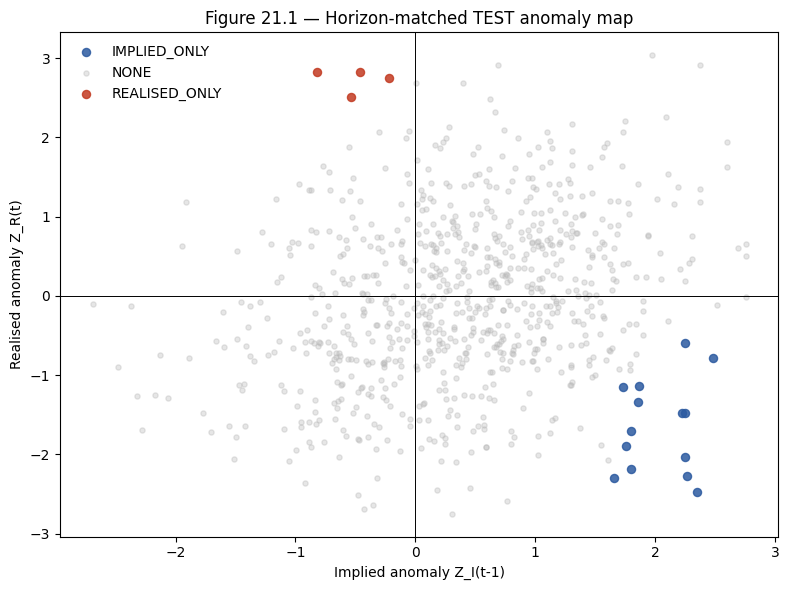

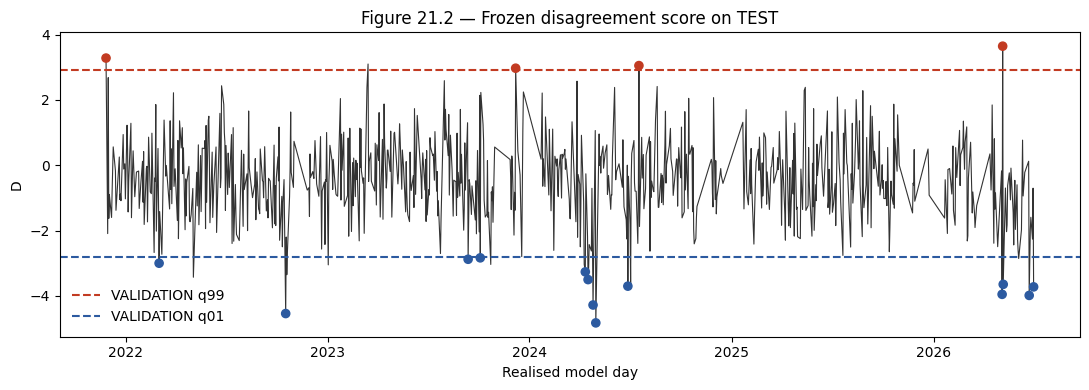

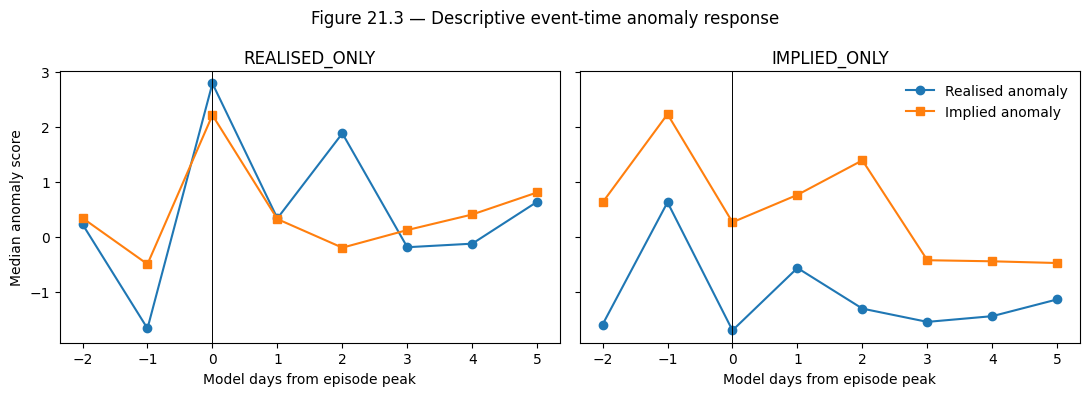

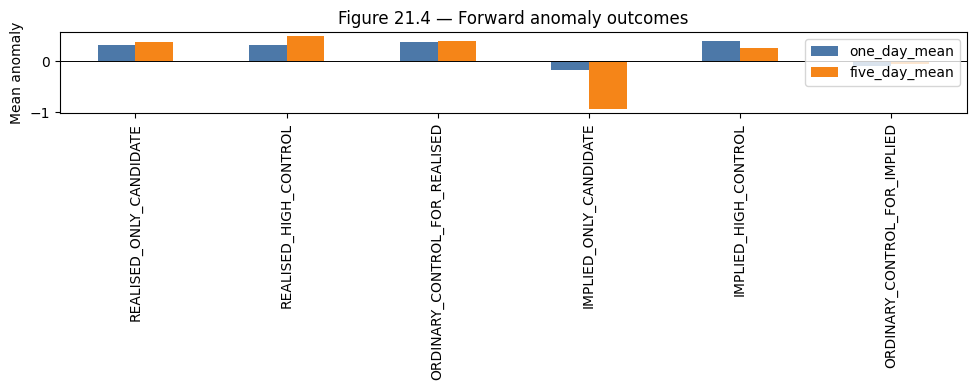

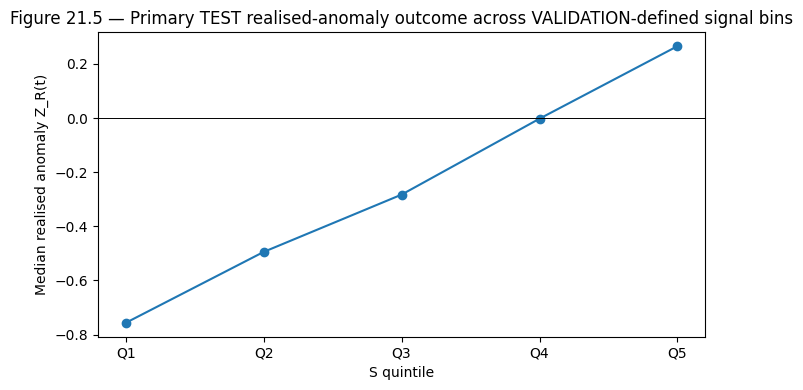

In [13]:
plt.style.use("default")
candidate_colors = {"NONE":"#b8b8b8","REALISED_ONLY":"#c23b22","IMPLIED_ONLY":"#2c5aa0"}

fig, ax = plt.subplots(figsize=(8,6))
for kind, group in test_scores.groupby("candidate_type"):
    ax.scatter(group["Z_I_prev"], group["Z_R"], s=34 if kind!="NONE" else 14,
               alpha=.85 if kind!="NONE" else .35, c=candidate_colors[kind], label=kind)
ax.axhline(0,color="black",lw=.7); ax.axvline(0,color="black",lw=.7)
ax.set(xlabel="Implied anomaly Z_I(t-1)",ylabel="Realised anomaly Z_R(t)",
       title="Figure 21.1 — Horizon-matched TEST anomaly map")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_1_anomaly_map.png",dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(test_scores["realised_model_day"],test_scores["D"],color="#333333",lw=.8)
ax.axhline(q_high,color="#c23b22",ls="--",label="VALIDATION q99")
ax.axhline(q_low,color="#2c5aa0",ls="--",label="VALIDATION q01")
peaks=set(episodes["peak_day"]) if len(episodes) else set()
pk=test_scores.loc[test_scores["realised_model_day"].isin(peaks)]
ax.scatter(pk["realised_model_day"],pk["D"],c=pk["candidate_type"].map(candidate_colors),s=35,zorder=3)
ax.set(title="Figure 21.2 — Frozen disagreement score on TEST",ylabel="D",xlabel="Realised model day")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_2_disagreement_time.png",dpi=180); plt.show()

event_time=[]
for row in episodes.itertuples(index=False):
    for h in range(-2,6):
        idx=row.canonical_index+h
        hit=daily.loc[daily["canonical_index"].eq(idx)]
        if len(hit): event_time.append({"candidate_type":row.candidate_type,"horizon":h,
                                        "Z_R":hit["Z_R"].iloc[0],"Z_I":hit["Z_I"].iloc[0]})
event_time=pd.DataFrame(event_time)
fig, axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,kind in zip(axes,["REALISED_ONLY","IMPLIED_ONLY"]):
    g=event_time.loc[event_time["candidate_type"].eq(kind)] if len(event_time) else pd.DataFrame()
    if len(g):
        m=g.groupby("horizon")[["Z_R","Z_I"]].median()
        ax.plot(m.index,m["Z_R"],marker="o",label="Realised anomaly")
        ax.plot(m.index,m["Z_I"],marker="s",label="Implied anomaly")
    ax.axvline(0,color="black",lw=.7);ax.set(title=kind,xlabel="Model days from episode peak")
axes[0].set_ylabel("Median anomaly score");axes[1].legend(frameon=False)
fig.suptitle("Figure 21.3 — Descriptive event-time anomaly response");fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_3_event_time_response.png",dpi=180);plt.show()

fig,ax=plt.subplots(figsize=(10,4))
plot_forward=forward_information.set_index("analysis_group")[["one_day_mean","five_day_mean"]]
plot_forward.plot(kind="bar",ax=ax,color=["#4c78a8","#f58518"])
ax.axhline(0,color="black",lw=.7);ax.set(title="Figure 21.4 — Forward anomaly outcomes",ylabel="Mean anomaly",xlabel="")
fig.tight_layout();fig.savefig(FIGURES/"21_figure_21_4_forward_information.png",dpi=180);plt.show()

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(quintile_summary["validation_defined_quintile"].astype(str),quintile_summary["primary_median_Z_R"],marker="o")
ax.axhline(0,color="black",lw=.7);ax.set(title="Figure 21.5 — Primary TEST realised-anomaly outcome across VALIDATION-defined signal bins",
                                       xlabel="S quintile", ylabel="Median realised anomaly Z_R(t)")
fig.tight_layout();fig.savefig(FIGURES/"21_figure_21_5_signal_bins.png",dpi=180);plt.show()

## 14. Core tables and exports

In [14]:
table_21_1 = pd.DataFrame([{
    "flexible_models": " | ".join(FLEXIBLE_MODELS),
    "minimum_model_support": MIN_MODEL_SUPPORT,
    "validation_detector_n": len(validation_detector),
    "active_channel_percentile": ACTIVE_THRESHOLD,
    "q_low": q_low, "q_high": q_high, "S_cheap": S_cheap, "S_rich": S_rich,
    "primary_horizon": 1, "secondary_horizon": 5,
    "event_exclusion": "six frozen families on R_t or I_(t-1) target day",
}])
table_21_2 = episodes.copy()
table_21_3 = forward_information.assign(result_family="EXERCISE_7A")
signal_primary_table = signal_summary[[
    "signal_group", "n", "primary_mean_Z_R", "primary_median_Z_R",
    "primary_mean_P_R", "primary_median_P_R", "primary_P_R_ge_0_95_rate",
    "primary_mean_Z_R_ci_low", "primary_mean_Z_R_ci_high",
    "primary_median_Z_R_ci_low", "primary_median_Z_R_ci_high",
    "primary_P_R_ge_0_95_rate_ci_low", "primary_P_R_ge_0_95_rate_ci_high",
    "bootstrap_valid_replicates", "bootstrap_valid_fraction",
]].assign(result_family="EXERCISE_7B_PRIMARY_PREDICTIVE")
signal_secondary_table = signal_summary[[
    "signal_group", "secondary_n_Y", "secondary_mean_Y", "secondary_median_Y",
    "secondary_median_R_over_I_prev", "secondary_directional_hit_rate",
    "secondary_mean_Y_ci_low", "secondary_mean_Y_ci_high",
    "secondary_median_Y_ci_low", "secondary_median_Y_ci_high",
    "secondary_directional_hit_rate_ci_low", "secondary_directional_hit_rate_ci_high",
]].assign(result_family="EXERCISE_7B_SECONDARY_ECONOMIC_DIAGNOSTIC")

run_metadata = pd.DataFrame([{
    "notebook": "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
    "upstream_ratios": "20_api_ordinary_response_ratios.csv",
    "upstream_models": " | ".join(FLEXIBLE_MODELS),
    "cdf_calibration_sample": "VALIDATION_ONLY",
    "threshold_calibration_sample": "VALIDATION_ONLY",
    "test_role": "EVALUATION_ONLY",
    "pairing": "previous canonical model-day row",
    "models_refit": False, "models_reselected": False,
    "calendar_used_after_classification": True,
    "forward_horizons": "exact canonical t+1 and fixed t+1...t+5",
    "exercise_7a_controls": "independent directional masks; dual-high allowed",
    "exercise_7b_primary_outcome": "Z_R and P_R; Y secondary economic diagnostic",
    "exercise_7b_bootstrap": "full TEST canonical chronology moving blocks, length 5, then group statistics",
    "upstream_files_modified": False,
    "bootstrap_reps": BOOTSTRAP_REPS, "bootstrap_seed": BOOTSTRAP_SEED,
}])

exports = {
    "21_hidden_event_daily_scores.csv": test_eval,
    "21_hidden_event_thresholds.csv": thresholds.assign(S_cheap=S_cheap, S_rich=S_rich),
    "21_hidden_event_episodes.csv": episodes,
    "21_hidden_event_calendar_annotations.csv": annotations,
    "21_hidden_event_forward_information.csv": forward_information,
    "21_volatility_disagreement_signal.csv": signal_test,
    "21_volatility_disagreement_signal_summary.csv": signal_summary,
    "21_robustness_summary.csv": robustness_summary,
    "21_run_metadata.csv": run_metadata,
}
for name, frame in exports.items():
    frame.to_csv(PROCESSED / name, index=False)

display(table_21_1)
display(table_21_2)
display(table_21_3)
display(signal_primary_table)
display(signal_secondary_table)

,flexible_models,minimum_model_support,validation_detector_n,active_channel_percentile,q_low,q_high,S_cheap,S_rich,primary_horizon,secondary_horizon,event_exclusion
0,RANDOM_FOREST | GRADIENT_BOOSTING | MLP | TRAN...,3,799,0.95,-2.822486,2.915663,-0.303923,0.49818,1,5,six frozen families on R_t or I_(t-1) target day


,episode_id,candidate_type,start_day,end_day,n_days,peak_day,implied_reference_day,peak_D,P_R,P_I_prev,...,Z_I_next5_mean,n_Z_R_next5,n_Z_I_next5,implied_catches_up_same_day,implied_catches_up_next_day,realised_materialises_next_day,possible_timing_or_delayed_response,n_models_flagging_same_direction,models_flagging_same_direction,model_agreement_label
0,E21_001,REALISED_ONLY,2021-11-26,2021-11-26,1,2021-11-26,2021-11-25,3.281560,0.997605,0.322485,...,0.521034,4,4,True,False,False,True,3,MLP | RANDOM_FOREST | TRANSFORMER,STRONG_3_OF_4
1,E21_002,IMPLIED_ONLY,2022-03-02,2022-03-02,1,2022-03-02,2022-03-01,-2.999231,0.127545,0.968639,...,1.388123,3,2,False,False,False,False,2,GRADIENT_BOOSTING | RANDOM_FOREST,MODERATE_2_OF_4
2,E21_003,IMPLIED_ONLY,2022-10-17,2022-10-17,1,2022-10-17,2022-10-14,-4.539998,0.011377,0.988166,...,1.229767,4,4,False,False,False,False,4,GRADIENT_BOOSTING | MLP | RANDOM_FOREST | TRAN...,HIGH_4_OF_4
3,E21_004,IMPLIED_ONLY,2023-09-12,2023-09-12,1,2023-09-12,2023-09-11,-2.878268,0.126347,0.958580,...,-0.425960,4,5,False,False,False,False,0,,CONSENSUS_ONLY_OR_WEAK
4,E21_005,IMPLIED_ONLY,2023-10-04,2023-10-04,1,2023-10-04,2023-10-03,-2.834738,0.277246,0.987574,...,-0.492445,4,3,False,False,False,False,2,RANDOM_FOREST | TRANSFORMER,MODERATE_2_OF_4
5,E21_006,REALISED_ONLY,2023-12-07,2023-12-07,1,2023-12-07,2023-12-06,2.971265,0.997006,0.411834,...,0.575783,2,3,False,False,False,False,1,TRANSFORMER,CONSENSUS_ONLY_OR_WEAK
6,E21_007,IMPLIED_ONLY,2024-04-11,2024-04-11,1,2024-04-11,2024-04-10,-3.264406,0.217365,0.993491,...,1.332088,5,4,False,False,False,False,3,GRADIENT_BOOSTING | RANDOM_FOREST | TRANSFORMER,STRONG_3_OF_4
7,E21_008,IMPLIED_ONLY,2024-04-16,2024-04-17,2,2024-04-16,2024-04-15,-3.500630,0.044311,0.963905,...,0.082966,4,4,False,False,False,False,2,GRADIENT_BOOSTING | MLP,MODERATE_2_OF_4
8,E21_009,IMPLIED_ONLY,2024-04-25,2024-04-25,1,2024-04-25,2024-04-24,-4.278046,0.020958,0.987574,...,0.882784,3,3,False,False,False,False,4,GRADIENT_BOOSTING | MLP | RANDOM_FOREST | TRAN...,HIGH_4_OF_4
9,E21_010,IMPLIED_ONLY,2024-04-30,2024-04-30,1,2024-04-30,2024-04-29,-4.825850,0.006587,0.990533,...,-1.388265,3,3,False,False,False,False,3,GRADIENT_BOOSTING | MLP | RANDOM_FOREST,STRONG_3_OF_4


,analysis_group,analysis_side,mask_column,n,n_one_day,n_five_day,forward_channel,one_day_mean,one_day_median,five_day_mean,five_day_median,mean_convergence,one_day_ci_low,one_day_ci_high,exploratory_small_sample,result_family
0,REALISED_ONLY_CANDIDATE,REALISED,is_realised_only_candidate,4,2,4,I,0.319548,0.319548,0.375480,0.548408,-0.788574,0.005933,0.633163,True,EXERCISE_7A
1,REALISED_HIGH_CONTROL,REALISED,is_realised_high_control,38,34,38,I,0.312388,0.389318,0.495660,0.537035,0.078478,-0.015939,0.622289,False,EXERCISE_7A
2,ORDINARY_CONTROL_FOR_REALISED,REALISED,is_ordinary_control,685,535,684,I,0.383395,0.413432,0.391602,0.454040,0.090883,0.308956,0.458080,False,EXERCISE_7A
3,IMPLIED_ONLY_CANDIDATE,IMPLIED,is_implied_only_candidate,13,8,12,R,-0.176008,-0.569014,-0.942958,-0.925633,-1.577714,-1.220253,0.996154,False,EXERCISE_7A
4,IMPLIED_HIGH_CONTROL,IMPLIED,is_implied_high_control,52,43,52,R,0.401268,0.491950,0.250265,0.256468,-0.459713,0.047604,0.746717,False,EXERCISE_7A
5,ORDINARY_CONTROL_FOR_IMPLIED,IMPLIED,is_ordinary_control,685,528,678,R,-0.097847,-0.125661,-0.045969,0.053155,0.090883,-0.188281,-0.012562,False,EXERCISE_7A


,signal_group,n,primary_mean_Z_R,primary_median_Z_R,primary_mean_P_R,primary_median_P_R,primary_P_R_ge_0_95_rate,primary_mean_Z_R_ci_low,primary_mean_Z_R_ci_high,primary_median_Z_R_ci_low,primary_median_Z_R_ci_high,primary_P_R_ge_0_95_rate_ci_low,primary_P_R_ge_0_95_rate_ci_high,bootstrap_valid_replicates,bootstrap_valid_fraction,result_family
0,IMPLIED_CHEAP,19,-0.853483,-0.795458,0.245288,0.213174,0.000000,-1.153282,-0.461259,-1.291856,-0.634509,0.000000,0.000000,5000,1.0,EXERCISE_7B_PRIMARY_PREDICTIVE
1,IMPLIED_RICH,90,0.221920,0.293246,0.561943,0.615269,0.088889,-0.017829,0.492623,0.044168,0.520959,0.036145,0.148157,5000,1.0,EXERCISE_7B_PRIMARY_PREDICTIVE
2,NEUTRAL,716,-0.039768,-0.086414,0.487222,0.465569,0.055866,-0.136586,0.054727,-0.191793,0.037552,0.040000,0.073276,5000,1.0,EXERCISE_7B_PRIMARY_PREDICTIVE


,signal_group,secondary_n_Y,secondary_mean_Y,secondary_median_Y,secondary_median_R_over_I_prev,secondary_directional_hit_rate,secondary_mean_Y_ci_low,secondary_mean_Y_ci_high,secondary_median_Y_ci_low,secondary_median_Y_ci_high,secondary_directional_hit_rate_ci_low,secondary_directional_hit_rate_ci_high,result_family
0,IMPLIED_CHEAP,19,-0.339243,-0.321029,0.725402,0.210526,-0.552028,-0.089204,-0.620250,-0.140001,0.045455,0.434783,EXERCISE_7B_SECONDARY_ECONOMIC_DIAGNOSTIC
1,IMPLIED_RICH,90,-0.687157,-0.652938,0.520515,0.822222,-0.854922,-0.502256,-0.835472,-0.467808,0.738632,0.897436,EXERCISE_7B_SECONDARY_ECONOMIC_DIAGNOSTIC
2,NEUTRAL,716,-0.447619,-0.461780,0.630162,NaN,-0.508107,-0.390148,-0.525220,-0.370532,NaN,NaN,EXERCISE_7B_SECONDARY_ECONOMIC_DIAGNOSTIC


## 15. Final assertions and empirical summary

In [15]:
# Frozen-design and final-correction assertions.
assert not test_scores["sample_split"].eq("train").any()
assert set(validation_detector["sample_split"]) == {"validation"}
assert thresholds.loc[0, "cdf_sample"] == "VALIDATION_ONLY"
assert panel["previous_model_day"].equals(panel["model_day"].shift(1))
assert panel["next_model_day"].equals(panel["model_day"].shift(-1))
assert pairs["sample_split"].eq(pairs["previous_sample_split"]).all()
assert not test_scores.loc[test_scores["candidate_type"].ne("NONE"), "is_known_primary_event_pair"].any()
assert primary_candidate_snapshot.sort_values("realised_model_day").reset_index(drop=True).equals(
    test_scores[["realised_model_day", "candidate_type"]].sort_values("realised_model_day").reset_index(drop=True)
)
assert primary_episode_snapshot.sort_values("realised_model_day").reset_index(drop=True).equals(
    candidate_days[["realised_model_day", "candidate_type", "episode_id"]].sort_values("realised_model_day").reset_index(drop=True)
)
assert frozen_primary_episode_assignment.equals(
    candidate_days[["realised_model_day", "candidate_type", "episode_id"]].reset_index(drop=True)
)
assert run_metadata.loc[0, "calendar_used_after_classification"]
assert pairs["n_models_R"].ge(3).all() and pairs["n_models_I_prev"].ge(3).all()
assert not run_metadata.loc[0, "models_refit"] and not run_metadata.loc[0, "models_reselected"]
assert not run_metadata.loc[0, "upstream_files_modified"]
assert np.allclose(
    ratio_percentiles["response_ratio"],
    ratio_percentiles["actual"] / ratio_percentiles["background_forecast"],
    rtol=1e-12, atol=1e-14,
)
assert signal["sample_split"].eq(signal["previous_sample_split"]).all()
assert signal["n_models"].ge(3).all()
assert np.allclose(
    signal.loc[signal["Y"].notna(), "Y"],
    np.log(signal.loc[signal["Y"].notna(), "R"] / signal.loc[signal["Y"].notna(), "I_prev"]),
)
assert not np.isinf(test_scores.select_dtypes(include=[np.number])).any().any()
assert not np.isinf(signal_test.select_dtypes(include=[np.number])).any().any()
assert episodes["episode_id"].is_unique
assert (annotations.loc[annotations["annotation_status"].eq("MULTIPLE_EVENTS"), "n_exact_coherent_families"] > 1).all()
assert (annotations.loc[annotations["n_exact_coherent_families"].le(1), "annotation_status"] != "MULTIPLE_EVENTS").all()

one_day = test_eval.loc[test_eval["one_day_model_day"].notna(), ["realised_model_day", "one_day_model_day"]]
positions = panel.set_index("model_day")["canonical_index"]
assert (one_day["one_day_model_day"].map(positions).to_numpy()
        == one_day["realised_model_day"].map(positions).to_numpy() + 1).all()
for h in range(1, 6):
    valid_h = daily[f"model_day_plus_{h}"].notna()
    assert (daily.loc[valid_h, f"model_day_plus_{h}"].map(positions).to_numpy()
            == daily.loc[valid_h, "canonical_index"].to_numpy() + h).all()
assert daily["n_Z_R_next5"].le(5).all() and daily["n_Z_I_next5"].le(5).all()

primary_7a_masks = [
    "is_realised_only_candidate", "is_implied_only_candidate",
    "is_realised_high_control", "is_implied_high_control", "is_ordinary_control",
]
assert not test_eval.loc[test_eval[primary_7a_masks].any(axis=1), "is_known_primary_event_pair"].any()
assert test_eval.loc[test_eval["is_realised_high_control"], "P_R"].ge(ACTIVE_THRESHOLD).all()
assert test_eval.loc[test_eval["is_implied_high_control"], "P_I_prev"].ge(ACTIVE_THRESHOLD).all()
assert (
    test_eval.loc[test_eval["is_ordinary_control"], "P_R"].lt(ACTIVE_THRESHOLD)
    & test_eval.loc[test_eval["is_ordinary_control"], "P_I_prev"].lt(ACTIVE_THRESHOLD)
).all()
assert test_eval["is_dual_high_control"].equals(
    test_eval["is_realised_high_control"] & test_eval["is_implied_high_control"]
)

realised_eps = episodes["candidate_type"].eq("REALISED_ONLY")
assert episodes.loc[realised_eps, "implied_catches_up_same_day"].equals(
    (episodes.loc[realised_eps, "P_I_same"].ge(ACTIVE_THRESHOLD)).rename("implied_catches_up_same_day")
)
assert {"primary_mean_Z_R", "primary_median_Z_R", "primary_mean_P_R",
        "primary_P_R_ge_0_95_rate"}.issubset(signal_summary.columns)
assert {"secondary_mean_Y", "secondary_median_Y", "secondary_directional_hit_rate"}.issubset(signal_summary.columns)
assert BOOTSTRAP_REPS == 5_000 and BOOTSTRAP_SEED == 21 and BLOCK_LENGTH == 5
assert signal_test_chronology["canonical_index"].diff().dropna().eq(1).all()
assert signal_summary["bootstrap_valid_replicates"].between(0, BOOTSTRAP_REPS).all()
assert signal_summary["bootstrap_valid_fraction"].between(0, 1).all()
assert "full TEST canonical chronology" in run_metadata.loc[0, "exercise_7b_bootstrap"]
assert candidate_agreement["n_models_flagging_same_direction"].between(0, 4).all()
assert set(candidate_agreement["model_agreement_label"]).issubset(
    {"HIGH_4_OF_4", "STRONG_3_OF_4", "MODERATE_2_OF_4", "CONSENSUS_ONLY_OR_WEAK"}
)
exported_thresholds = pd.read_csv(PROCESSED / "21_hidden_event_thresholds.csv")
assert np.isclose(exported_thresholds.loc[0, "disagreement_q_low"], q_low)
assert np.isclose(exported_thresholds.loc[0, "disagreement_q_high"], q_high)
assert np.isclose(exported_thresholds.loc[0, "S_cheap"], S_cheap)
assert np.isclose(exported_thresholds.loc[0, "S_rich"], S_rich)

n_primary_days = len(candidate_days)
n_realised = int(episodes["candidate_type"].eq("REALISED_ONLY").sum())
n_implied = int(episodes["candidate_type"].eq("IMPLIED_ONLY").sum())
n_exact = int(episodes["n_exact_coherent_families"].gt(0).sum()) if len(episodes) else 0
n_multiple = int(episodes["annotation_status"].eq("MULTIPLE_EVENTS").sum()) if len(episodes) else 0
n_unexplained = int(episodes["annotation_status"].eq("NO_CALENDAR_MATCH").sum()) if len(episodes) else 0
n_same = int(episodes.loc[realised_eps, "implied_catches_up_same_day"].sum())
n_next = int(episodes.loc[realised_eps, "implied_catches_up_next_day"].sum())
n_materialise = int(episodes.loc[episodes["candidate_type"].eq("IMPLIED_ONLY"), "realised_materialises_next_day"].sum())
sig = signal_summary.set_index("signal_group")
rich, neutral, cheap = sig.loc["IMPLIED_RICH"], sig.loc["NEUTRAL"], sig.loc["IMPLIED_CHEAP"]
cc = control_counts.iloc[0]
monotonic = bool(
    quintile_summary["primary_median_Z_R"].dropna().is_monotonic_increasing
    or quintile_summary["primary_median_Z_R"].dropna().is_monotonic_decreasing
)

display(Markdown(f"""
### Final corrected empirical summary

**Exercise 6.** The unchanged detector yields **{n_primary_days} primary candidate days**, collapsed into **{n_realised} REALISED_ONLY** and **{n_implied} IMPLIED_ONLY** TEST episodes. Agreement at primary candidate days is {agreement_counts["HIGH_4_OF_4"]} high (4/4), {agreement_counts["STRONG_3_OF_4"]} strong (3/4), {agreement_counts["MODERATE_2_OF_4"]} moderate (2/4), and {agreement_counts["CONSENSUS_ONLY_OR_WEAK"]} weak (0/1). Post-discovery calendar matching finds {n_exact} exact coherent-family episode matches, including {n_multiple} with multiple distinct families, and {n_unexplained} with no match.

**Timing.** Among REALISED_ONLY episodes, {n_same} show same-day implied catch-up and {n_next} show next-day implied catch-up; {n_materialise} IMPLIED_ONLY episodes show next-day realised materialisation. These remain descriptive timing-consistent explanations, not reclassification rules.

**Exercise 7A.** Independent directional masks give {cc["n_realised_high_controls"]} realised-high controls, {cc["n_implied_high_controls"]} implied-high controls, {cc["n_ordinary_controls"]} ordinary controls, and {cc["n_dual_high_controls"]} dual-high controls. All exclude known-primary pairs and use exact canonical t+1 and fixed t+1...t+5 windows; small candidate groups remain exploratory.

**Exercise 7B — primary predictive outcome.** Mean/median realised anomaly Z_R is {rich["primary_mean_Z_R"]:.3f}/{rich["primary_median_Z_R"]:.3f} for IMPLIED_RICH, {neutral["primary_mean_Z_R"]:.3f}/{neutral["primary_median_Z_R"]:.3f} for NEUTRAL, and {cheap["primary_mean_Z_R"]:.3f}/{cheap["primary_median_Z_R"]:.3f} for IMPLIED_CHEAP. Their 95% full-chronology moving-block CIs for mean Z_R are [{rich["primary_mean_Z_R_ci_low"]:.3f}, {rich["primary_mean_Z_R_ci_high"]:.3f}], [{neutral["primary_mean_Z_R_ci_low"]:.3f}, {neutral["primary_mean_Z_R_ci_high"]:.3f}], and [{cheap["primary_mean_Z_R_ci_low"]:.3f}, {cheap["primary_mean_Z_R_ci_high"]:.3f}], with usable-replicate fractions {rich["bootstrap_valid_fraction"]:.3f}, {neutral["bootstrap_valid_fraction"]:.3f}, and {cheap["bootstrap_valid_fraction"]:.3f}. The validation-defined quintile medians are {"monotonic" if monotonic else "not strictly monotonic"} on TEST.

**Exercise 7B — secondary economic diagnostic.** Y = log(R_t / I_(t-1)) is reported only as the ex-post realised-versus-prior-implied spread. Because Y shares the frozen realised-background forecast algebraically with S, its directional hit rates are not independent evidence of predictive content.

No option-profitability or structural-causality claim is made.
"""))
print("Notebook 21 complete: final downstream corrections use untouched frozen validation-calibrated rules and TEST-only assessment.")


### Final corrected empirical summary

**Exercise 6.** The unchanged detector yields **18 primary candidate days**, collapsed into **4 REALISED_ONLY** and **13 IMPLIED_ONLY** TEST episodes. Agreement at primary candidate days is 4 high (4/4), 5 strong (3/4), 7 moderate (2/4), and 2 weak (0/1). Post-discovery calendar matching finds 16 exact coherent-family episode matches, including 15 with multiple distinct families, and 0 with no match.

**Timing.** Among REALISED_ONLY episodes, 3 show same-day implied catch-up and 0 show next-day implied catch-up; 1 IMPLIED_ONLY episodes show next-day realised materialisation. These remain descriptive timing-consistent explanations, not reclassification rules.

**Exercise 7A.** Independent directional masks give 38 realised-high controls, 52 implied-high controls, 685 ordinary controls, and 6 dual-high controls. All exclude known-primary pairs and use exact canonical t+1 and fixed t+1...t+5 windows; small candidate groups remain exploratory.

**Exercise 7B — primary predictive outcome.** Mean/median realised anomaly Z_R is 0.222/0.293 for IMPLIED_RICH, -0.040/-0.086 for NEUTRAL, and -0.853/-0.795 for IMPLIED_CHEAP. Their 95% full-chronology moving-block CIs for mean Z_R are [-0.018, 0.493], [-0.137, 0.055], and [-1.153, -0.461], with usable-replicate fractions 1.000, 1.000, and 1.000. The validation-defined quintile medians are monotonic on TEST.

**Exercise 7B — secondary economic diagnostic.** Y = log(R_t / I_(t-1)) is reported only as the ex-post realised-versus-prior-implied spread. Because Y shares the frozen realised-background forecast algebraically with S, its directional hit rates are not independent evidence of predictive content.

No option-profitability or structural-causality claim is made.


Notebook 21 complete: final downstream corrections use untouched frozen validation-calibrated rules and TEST-only assessment.


## 16A. Calibration-transfer audit

This closure diagnostic asks whether quantities calibrated on ordinary non-primary VALIDATION observations transfer comparably to ordinary non-primary TEST observations. It does **not** recalibrate on TEST or modify the detector.

The consensus percentiles are medians of model-specific empirical percentiles, so their exceedance rates are benchmarked against the observed VALIDATION rates—not a nominal 5% Uniform benchmark. Only the frozen disagreement-tail thresholds retain 1% as a secondary nominal reference; the empirical VALIDATION rate remains primary.

In [16]:
# Defensive closure snapshots: appended validation work must not mutate the frozen detector.
closure_test_scores_snapshot = test_scores.copy(deep=True)
closure_candidate_days_snapshot = candidate_days.copy(deep=True)
closure_episodes_snapshot = episodes.copy(deep=True)
closure_validation_detector_snapshot = validation_detector.copy(deep=True)
closure_q_low, closure_q_high = float(q_low), float(q_high)

CALIBRATION_METRICS = [
    "P_R_GE_0_95", "P_I_PREV_GE_0_95", "D_GE_Q_HIGH", "D_LE_Q_LOW",
    "REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT",
]

def calibration_metric_matrix(frame):
    p_r = frame["P_R"].ge(ACTIVE_THRESHOLD).to_numpy()
    p_i = frame["P_I_prev"].ge(ACTIVE_THRESHOLD).to_numpy()
    d_hi = frame["D"].ge(q_high).to_numpy()
    d_lo = frame["D"].le(q_low).to_numpy()
    return np.column_stack([p_r, p_i, d_hi, d_lo, d_hi & p_r, d_lo & p_i])

def complete_split_chronology(split):
    chronology = panel.loc[
        panel["sample_split"].eq(split), ["model_day", "canonical_index"]
    ].copy()
    detector = pairs[[
        "realised_model_day", "sample_split", "P_R", "P_I_prev", "D",
        "is_known_primary_event_pair",
    ]].rename(columns={"realised_model_day": "model_day", "sample_split": "detector_split"})
    chronology = chronology.merge(detector, on="model_day", how="left", validate="one_to_one")
    required = chronology[["P_R", "P_I_prev", "D"]].notna().all(axis=1)
    chronology["eligible_ordinary_detector"] = (
        chronology["detector_split"].eq(split)
        & chronology["is_known_primary_event_pair"].eq(False)
        & required
    )
    chronology = chronology.sort_values("canonical_index").reset_index(drop=True)
    assert chronology["canonical_index"].diff().dropna().eq(1).all()
    return chronology

def chronology_rate_bootstrap(chronology, seed):
    n = len(chronology)
    starts = np.arange(n - BLOCK_LENGTH + 1)
    positions = chronology["canonical_index"].to_numpy()
    assert BLOCK_LENGTH == 5 and BOOTSTRAP_REPS == 5_000
    assert all(np.all(np.diff(positions[s:s + BLOCK_LENGTH]) == 1) for s in starts)
    eligible = chronology["eligible_ordinary_detector"].to_numpy(bool)
    metrics = calibration_metric_matrix(chronology)
    rng = np.random.default_rng(seed)
    blocks_needed = int(np.ceil(n / BLOCK_LENGTH))
    draws = np.full((BOOTSTRAP_REPS, len(CALIBRATION_METRICS)), np.nan)
    for rep in range(BOOTSTRAP_REPS):
        selected_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sampled = np.concatenate([
            np.arange(s, s + BLOCK_LENGTH) for s in selected_starts
        ])[:n]
        eligible_sample = eligible[sampled]
        if eligible_sample.any():
            draws[rep] = metrics[sampled][eligible_sample].mean(axis=0)
    observed = metrics[eligible].mean(axis=0)
    return observed, draws, int(eligible.sum())

validation_chronology = complete_split_chronology("validation")
test_chronology_closure = complete_split_chronology("test")
validation_rates, validation_rate_draws, validation_n = chronology_rate_bootstrap(
    validation_chronology, BOOTSTRAP_SEED + 1601
)
test_rates, test_rate_draws, test_n = chronology_rate_bootstrap(
    test_chronology_closure, BOOTSTRAP_SEED + 1602
)

calibration_rows = []
for j, metric in enumerate(CALIBRATION_METRICS):
    val_lo, val_hi = bootstrap_ci(validation_rate_draws[:, j])
    test_lo, test_hi = bootstrap_ci(test_rate_draws[:, j])
    difference_draws = test_rate_draws[:, j] - validation_rate_draws[:, j]
    diff_lo, diff_hi = bootstrap_ci(difference_draws)
    calibration_rows.append({
        "metric": metric,
        "validation_n": validation_n,
        "validation_rate": validation_rates[j],
        "validation_95pct_ci_low": val_lo,
        "validation_95pct_ci_high": val_hi,
        "test_n": test_n,
        "test_rate": test_rates[j],
        "test_95pct_ci_low": test_lo,
        "test_95pct_ci_high": test_hi,
        "test_minus_validation": test_rates[j] - validation_rates[j],
        "difference_95pct_ci_low": diff_lo,
        "difference_95pct_ci_high": diff_hi,
        "primary_benchmark": "EMPIRICAL_VALIDATION",
        "secondary_nominal_reference": 0.01 if metric in {"D_GE_Q_HIGH", "D_LE_Q_LOW"} else np.nan,
    })
calibration_transfer_audit = pd.DataFrame(calibration_rows)
calibration_transfer_audit.to_csv(PROCESSED / "21_calibration_transfer_audit.csv", index=False)
display(calibration_transfer_audit)

,metric,validation_n,validation_rate,validation_95pct_ci_low,validation_95pct_ci_high,test_n,test_rate,test_95pct_ci_low,test_95pct_ci_high,test_minus_validation,difference_95pct_ci_low,difference_95pct_ci_high,primary_benchmark,secondary_nominal_reference
0,P_R_GE_0_95,799,0.042553,0.029563,0.057105,787,0.053367,0.038107,0.070106,0.010814,-0.010557,0.031666,EMPIRICAL_VALIDATION,NaN
1,P_I_PREV_GE_0_95,799,0.046308,0.031824,0.062273,787,0.083863,0.062583,0.104870,0.037555,0.010943,0.063138,EMPIRICAL_VALIDATION,NaN
2,D_GE_Q_HIGH,799,0.010013,0.003741,0.017414,787,0.006353,0.001267,0.012197,-0.003659,-0.012636,0.004884,EMPIRICAL_VALIDATION,0.01
3,D_LE_Q_LOW,799,0.010013,0.003727,0.017263,787,0.027954,0.014981,0.041617,0.017942,0.002787,0.032459,EMPIRICAL_VALIDATION,0.01
4,REALISED_ONLY_JOINT,799,0.006258,0.001266,0.012408,787,0.005083,0.001214,0.010296,-0.001175,-0.008554,0.006154,EMPIRICAL_VALIDATION,NaN
5,IMPLIED_ONLY_JOINT,799,0.007509,0.002433,0.013837,787,0.017789,0.007752,0.028169,0.010280,-0.001652,0.021967,EMPIRICAL_VALIDATION,NaN


## 16B. Official Japanese Ministry of Finance intervention validation

This external validation tests whether frozen hidden-event episodes are temporally associated with independently recorded official Japanese FX intervention dates. The official file supplies intervention dates but no intraday timestamps. Because the model day turns at 17:00 New York, economic assignment can carry approximately one model-day ambiguity; no intraday time is invented. The pre-specified ±5 model-day window is primary, with ±7 and ±10 as sensitivity checks. Association is not causal identification or evidence that the detector “predicted” intervention.

In [17]:
MOF_RAW = ROOT / "Data" / "foreign_exchange_intervention_operations.csv"
assert MOF_RAW.exists()
with MOF_RAW.open("r", encoding="cp932") as handle:
    mof_lines = handle.readlines()
mof_header_row = next(
    i for i, line in enumerate(mof_lines)
    if "Year" in line and "Currency pairs" in line
)
mof_raw = pd.read_csv(MOF_RAW, encoding="cp932", skiprows=mof_header_row)
mof_raw["source_row_number"] = np.arange(mof_header_row + 2, mof_header_row + 2 + len(mof_raw))

year = pd.to_numeric(mof_raw["Year"], errors="coerce").ffill()
month_text = mof_raw["Month"].astype("string").replace({"": pd.NA}).ffill()
day = pd.to_numeric(mof_raw["Day"], errors="coerce")
amount = pd.to_numeric(
    mof_raw["金額(amount)"].astype("string").str.replace(",", "", regex=False),
    errors="coerce",
)
currency_direction = mof_raw["Currency pairs"].astype("string")
date_text = (
    year.round().astype("Int64").astype("string") + "-"
    + month_text + "-" + day.round().astype("Int64").astype("string")
)
intervention_date = pd.to_datetime(date_text, format="%Y-%b-%d", errors="coerce")
usd_jpy = (
    currency_direction.str.contains("US dollar", case=False, na=False)
    & currency_direction.str.contains("Japanese yen", case=False, na=False)
)
clean_rows = pd.DataFrame({
    "intervention_date": intervention_date,
    "amount_100m_yen": amount,
    "currency_direction": currency_direction,
    "source_row_number": mof_raw["source_row_number"],
}).loc[usd_jpy & intervention_date.notna() & amount.notna()].copy()
clean_rows["standardised_currency_direction"] = np.select(
    [
        clean_rows["currency_direction"].str.contains(r"US dollar \(sold\).*Japanese yen \(bought\)", case=False, regex=True),
        clean_rows["currency_direction"].str.contains(r"US dollar \(bought\).*Japanese yen \(sold\)", case=False, regex=True),
    ],
    ["USD_SOLD_JPY_BOUGHT", "USD_BOUGHT_JPY_SOLD"],
    default="USD_JPY_OTHER",
)

test_panel_closure = panel.loc[panel["sample_split"].eq("test")].sort_values("canonical_index").copy()
assert len(test_panel_closure) == 1209
assert test_panel_closure["canonical_index"].diff().dropna().eq(1).all()
test_start, test_end = test_panel_closure["model_day"].min(), test_panel_closure["model_day"].max()
clean_rows = clean_rows.loc[clean_rows["intervention_date"].between(test_start, test_end)].copy()
mof_interventions_clean = (
    clean_rows.groupby("intervention_date", as_index=False)
    .agg(
        amount_100m_yen=("amount_100m_yen", "sum"),
        currency_direction=("currency_direction", lambda s: " | ".join(sorted(set(s.astype(str))))),
        source_row_number=("source_row_number", "min"),
        standardised_currency_direction=("standardised_currency_direction", lambda s: " | ".join(sorted(set(s.astype(str))))),
    )
    .sort_values("intervention_date")
    .reset_index(drop=True)
)
assert len(mof_interventions_clean) == 10

test_dates = test_panel_closure["model_day"].to_numpy(dtype="datetime64[ns]")
test_indices = test_panel_closure["canonical_index"].to_numpy(int)
mapped_rows = []
for row in mof_interventions_clean.itertuples(index=False):
    target = np.datetime64(row.intervention_date)
    position = int(np.searchsorted(test_dates, target, side="left"))
    if position < len(test_dates) and test_dates[position] == target:
        status = "EXACT_SAME_LABELLED_MODEL_DAY"
    else:
        status = "NEXT_AVAILABLE_CANONICAL_MODEL_DAY"
        assert position < len(test_dates)
    mapped_rows.append({
        **row._asdict(),
        "mapped_model_day": pd.Timestamp(test_dates[position]),
        "mapped_canonical_index": int(test_indices[position]),
        "mapping_status": status,
    })
mof_interventions_clean = pd.DataFrame(mapped_rows)

mof_interventions_clean["new_campaign"] = (
    mof_interventions_clean["intervention_date"].diff().dt.days.fillna(999).gt(5)
)
mof_interventions_clean["campaign_number"] = mof_interventions_clean["new_campaign"].cumsum().astype(int)
mof_interventions_clean["campaign_id"] = (
    "MOF_CAMPAIGN_" + mof_interventions_clean["campaign_number"].astype(str).str.zfill(2)
)
mof_intervention_campaigns = (
    mof_interventions_clean.groupby("campaign_id", as_index=False)
    .agg(
        campaign_start_date=("intervention_date", "min"),
        campaign_end_date=("intervention_date", "max"),
        n_intervention_dates=("intervention_date", "nunique"),
        total_amount_100m_yen=("amount_100m_yen", "sum"),
    )
)
assert len(mof_intervention_campaigns) == 5
mof_interventions_clean.to_csv(PROCESSED / "21_mof_interventions_clean.csv", index=False)
mof_intervention_campaigns.to_csv(PROCESSED / "21_mof_intervention_campaigns.csv", index=False)
display(mof_interventions_clean)
display(mof_intervention_campaigns)

,intervention_date,amount_100m_yen,currency_direction,source_row_number,standardised_currency_direction,mapped_model_day,mapped_canonical_index,mapping_status,new_campaign,campaign_number,campaign_id
0,2022-09-22,28382,the US dollar (sold) the Japanese yen (bought),517,USD_SOLD_JPY_BOUGHT,2022-09-22,5058,EXACT_SAME_LABELLED_MODEL_DAY,True,1,MOF_CAMPAIGN_01
1,2022-10-21,56202,the US dollar (sold) the Japanese yen (bought),519,USD_SOLD_JPY_BOUGHT,2022-10-21,5079,EXACT_SAME_LABELLED_MODEL_DAY,True,2,MOF_CAMPAIGN_02
2,2022-10-24,7296,the US dollar (sold) the Japanese yen (bought),520,USD_SOLD_JPY_BOUGHT,2022-10-24,5080,EXACT_SAME_LABELLED_MODEL_DAY,False,2,MOF_CAMPAIGN_02
3,2024-04-29,59185,the US dollar (sold) the Japanese yen (bought),527,USD_SOLD_JPY_BOUGHT,2024-04-29,5475,EXACT_SAME_LABELLED_MODEL_DAY,True,3,MOF_CAMPAIGN_03
4,2024-05-01,38700,the US dollar (sold) the Japanese yen (bought),528,USD_SOLD_JPY_BOUGHT,2024-05-01,5477,EXACT_SAME_LABELLED_MODEL_DAY,False,3,MOF_CAMPAIGN_03
5,2024-07-11,31678,the US dollar (sold) the Japanese yen (bought),530,USD_SOLD_JPY_BOUGHT,2024-07-11,5528,EXACT_SAME_LABELLED_MODEL_DAY,True,4,MOF_CAMPAIGN_04
6,2024-07-12,23670,the US dollar (sold) the Japanese yen (bought),531,USD_SOLD_JPY_BOUGHT,2024-07-12,5529,EXACT_SAME_LABELLED_MODEL_DAY,False,4,MOF_CAMPAIGN_04
7,2026-04-30,62787,the US dollar (sold) the Japanese yen (bought),539,USD_SOLD_JPY_BOUGHT,2026-04-30,5998,EXACT_SAME_LABELLED_MODEL_DAY,True,5,MOF_CAMPAIGN_05
8,2026-05-04,7802,the US dollar (sold) the Japanese yen (bought),540,USD_SOLD_JPY_BOUGHT,2026-05-04,6000,EXACT_SAME_LABELLED_MODEL_DAY,False,5,MOF_CAMPAIGN_05
9,2026-05-06,46759,the US dollar (sold) the Japanese yen (bought),541,USD_SOLD_JPY_BOUGHT,2026-05-06,6002,EXACT_SAME_LABELLED_MODEL_DAY,False,5,MOF_CAMPAIGN_05


,campaign_id,campaign_start_date,campaign_end_date,n_intervention_dates,total_amount_100m_yen
0,MOF_CAMPAIGN_01,2022-09-22,2022-09-22,1,28382
1,MOF_CAMPAIGN_02,2022-10-21,2022-10-24,2,63498
2,MOF_CAMPAIGN_03,2024-04-29,2024-05-01,2,97885
3,MOF_CAMPAIGN_04,2024-07-11,2024-07-12,2,55348
4,MOF_CAMPAIGN_05,2026-04-30,2026-05-06,3,117348


,intervention_date,mapped_model_day,mapped_canonical_index,amount_100m_yen,currency_direction,campaign_id,nearest_episode_id,nearest_episode_type,nearest_episode_peak_day,signed_model_day_distance,absolute_model_day_distance,timing_relation,nearest_episode_tie,hit_within_5,hit_within_7,hit_within_10
0,2022-09-22,2022-09-22,5058,28382,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_01,E21_003,IMPLIED_ONLY,2022-10-17,17,17,POST_INTERVENTION,False,False,False,False
1,2022-10-21,2022-10-21,5079,56202,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_02,E21_003,IMPLIED_ONLY,2022-10-17,-4,4,PRE_INTERVENTION,False,True,True,True
2,2022-10-24,2022-10-24,5080,7296,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_02,E21_003,IMPLIED_ONLY,2022-10-17,-5,5,PRE_INTERVENTION,False,True,True,True
3,2024-04-29,2024-04-29,5475,59185,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_03,E21_010,IMPLIED_ONLY,2024-04-30,1,1,POST_INTERVENTION,False,True,True,True
4,2024-05-01,2024-05-01,5477,38700,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_03,E21_010,IMPLIED_ONLY,2024-04-30,-1,1,PRE_INTERVENTION,False,True,True,True
5,2024-07-11,2024-07-11,5528,31678,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_04,E21_012,REALISED_ONLY,2024-07-17,4,4,POST_INTERVENTION,False,True,True,True
6,2024-07-12,2024-07-12,5529,23670,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_04,E21_012,REALISED_ONLY,2024-07-17,3,3,POST_INTERVENTION,False,True,True,True
7,2026-04-30,2026-04-30,5998,62787,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_013,IMPLIED_ONLY,2026-05-05,3,3,POST_INTERVENTION,False,True,True,True
8,2026-05-04,2026-05-04,6000,7802,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_013,IMPLIED_ONLY,2026-05-05,1,1,POST_INTERVENTION,False,True,True,True
9,2026-05-06,2026-05-06,6002,46759,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_014,REALISED_ONLY,2026-05-06,0,0,CONTEMPORANEOUS,False,True,True,True


,window_model_days,specification_role,n_intervention_dates,date_hit_count,date_hit_rate,n_campaigns,campaign_hit_count,campaign_hit_rate,n_frozen_episodes,episode_overlap_count,...,date_hit_null_mean,date_hit_null_median,date_hit_null_q025,date_hit_null_q975,date_hit_exact_p_value,campaign_hit_null_mean,campaign_hit_null_median,campaign_hit_null_q025,campaign_hit_null_q975,campaign_hit_exact_p_value
0,5,PRIMARY,10,9,0.9,5,4,0.8,17,7,...,1.174524,0.0,0.0,5.0,0.001654,0.652605,0.0,0.0,2.0,0.004963
1,7,SENSITIVITY,10,9,0.9,5,4,0.8,17,7,...,1.497105,1.0,0.0,6.0,0.005790,0.804797,1.0,0.0,3.0,0.009926
2,10,SENSITIVITY,10,9,0.9,5,4,0.8,17,9,...,1.902399,2.0,0.0,7.0,0.010753,1.004136,1.0,0.0,3.0,0.019024


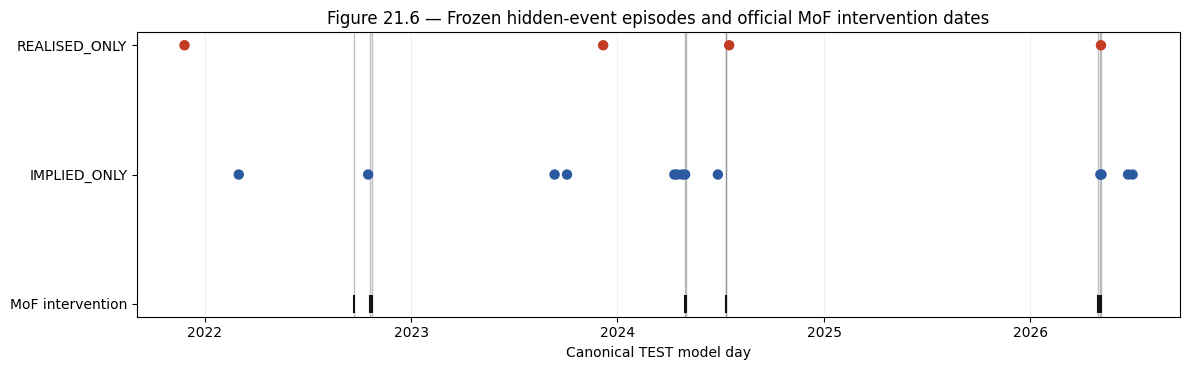

In [18]:
closure_episode_peaks = closure_episodes_snapshot[[
    "episode_id", "candidate_type", "peak_day", "canonical_index"
]].copy()
match_rows = []
for intervention in mof_interventions_clean.itertuples(index=False):
    distances = closure_episode_peaks["canonical_index"] - intervention.mapped_canonical_index
    absolute = distances.abs()
    minimum = int(absolute.min())
    tied = closure_episode_peaks.loc[absolute.eq(minimum)].sort_values(
        ["peak_day", "episode_id"]
    )
    chosen = tied.iloc[0]
    signed = int(chosen["canonical_index"] - intervention.mapped_canonical_index)
    relation = "PRE_INTERVENTION" if signed < 0 else "POST_INTERVENTION" if signed > 0 else "CONTEMPORANEOUS"
    match_rows.append({
        "intervention_date": intervention.intervention_date,
        "mapped_model_day": intervention.mapped_model_day,
        "mapped_canonical_index": intervention.mapped_canonical_index,
        "amount_100m_yen": intervention.amount_100m_yen,
        "currency_direction": intervention.currency_direction,
        "campaign_id": intervention.campaign_id,
        "nearest_episode_id": chosen["episode_id"],
        "nearest_episode_type": chosen["candidate_type"],
        "nearest_episode_peak_day": chosen["peak_day"],
        "signed_model_day_distance": signed,
        "absolute_model_day_distance": minimum,
        "timing_relation": relation,
        "nearest_episode_tie": len(tied) > 1,
        "hit_within_5": minimum <= 5,
        "hit_within_7": minimum <= 7,
        "hit_within_10": minimum <= 10,
    })
mof_intervention_matches = pd.DataFrame(match_rows)
WINDOWS = [5, 7, 10]
test_index_min = int(test_panel_closure["canonical_index"].min())
n_test = len(test_panel_closure)
episode_positions = closure_episode_peaks["canonical_index"].to_numpy(int) - test_index_min
intervention_positions = mof_interventions_clean["mapped_canonical_index"].to_numpy(int) - test_index_min
campaign_ids = mof_interventions_clean["campaign_id"].to_numpy(object)

null_rows = []
for shift in range(n_test):
    shifted_episode_positions = (episode_positions + shift) % n_test
    linear_distances = np.abs(
        intervention_positions[:, None] - shifted_episode_positions[None, :]
    )
    for window in WINDOWS:
        date_hits = (linear_distances <= window).any(axis=1)
        campaign_hits = {
            campaign_id: bool(date_hits[campaign_ids == campaign_id].any())
            for campaign_id in mof_intervention_campaigns["campaign_id"]
        }
        null_rows.append({
            "shift": shift,
            "window": window,
            "date_hit_count": int(date_hits.sum()),
            "campaign_hit_count": int(sum(campaign_hits.values())),
        })
mof_circular_shift_null = pd.DataFrame(null_rows)

summary_rows = []
for window in WINDOWS:
    hit_col = f"hit_within_{window}"
    date_hit = mof_intervention_matches[hit_col]
    hit_campaigns = mof_intervention_matches.loc[date_hit, "campaign_id"].nunique()
    episode_overlap = np.array([
        np.any(np.abs(intervention_positions - episode_position) <= window)
        for episode_position in episode_positions
    ])
    matched = mof_intervention_matches.loc[date_hit]
    null_window = mof_circular_shift_null.loc[mof_circular_shift_null["window"].eq(window)]
    observed_date_hits = int(date_hit.sum())
    observed_campaign_hits = int(hit_campaigns)
    summary_rows.append({
        "window_model_days": window,
        "specification_role": "PRIMARY" if window == 5 else "SENSITIVITY",
        "n_intervention_dates": len(mof_intervention_matches),
        "date_hit_count": observed_date_hits,
        "date_hit_rate": observed_date_hits / len(mof_intervention_matches),
        "n_campaigns": len(mof_intervention_campaigns),
        "campaign_hit_count": observed_campaign_hits,
        "campaign_hit_rate": observed_campaign_hits / len(mof_intervention_campaigns),
        "n_frozen_episodes": len(closure_episode_peaks),
        "episode_overlap_count": int(episode_overlap.sum()),
        "episode_overlap_rate": float(episode_overlap.mean()),
        "pre_intervention_matches": int(matched["timing_relation"].eq("PRE_INTERVENTION").sum()),
        "contemporaneous_matches": int(matched["timing_relation"].eq("CONTEMPORANEOUS").sum()),
        "post_intervention_matches": int(matched["timing_relation"].eq("POST_INTERVENTION").sum()),
        "date_hit_null_mean": null_window["date_hit_count"].mean(),
        "date_hit_null_median": null_window["date_hit_count"].median(),
        "date_hit_null_q025": null_window["date_hit_count"].quantile(.025),
        "date_hit_null_q975": null_window["date_hit_count"].quantile(.975),
        "date_hit_exact_p_value": float((null_window["date_hit_count"] >= observed_date_hits).mean()),
        "campaign_hit_null_mean": null_window["campaign_hit_count"].mean(),
        "campaign_hit_null_median": null_window["campaign_hit_count"].median(),
        "campaign_hit_null_q025": null_window["campaign_hit_count"].quantile(.025),
        "campaign_hit_null_q975": null_window["campaign_hit_count"].quantile(.975),
        "campaign_hit_exact_p_value": float((null_window["campaign_hit_count"] >= observed_campaign_hits).mean()),
    })
mof_intervention_validation_summary = pd.DataFrame(summary_rows)

mof_intervention_matches.to_csv(PROCESSED / "21_mof_intervention_matches.csv", index=False)
mof_circular_shift_null.to_csv(PROCESSED / "21_mof_circular_shift_null.csv", index=False)
mof_intervention_validation_summary.to_csv(
    PROCESSED / "21_mof_intervention_validation_summary.csv", index=False
)
display(mof_intervention_matches)
display(mof_intervention_validation_summary)

fig, ax = plt.subplots(figsize=(12, 3.8))
episode_y = closure_episode_peaks["candidate_type"].map({"IMPLIED_ONLY": 1, "REALISED_ONLY": 2})
episode_color = closure_episode_peaks["candidate_type"].map({"IMPLIED_ONLY": "#2c5aa0", "REALISED_ONLY": "#c23b22"})
ax.scatter(closure_episode_peaks["peak_day"], episode_y, c=episode_color, s=42, zorder=3)
for date in mof_interventions_clean["mapped_model_day"]:
    ax.axvline(date, color="#222222", alpha=.28, lw=1)
ax.scatter(mof_interventions_clean["mapped_model_day"], np.zeros(len(mof_interventions_clean)),
           marker="|", s=170, color="#111111", label="Official MoF intervention")
ax.set_yticks([0, 1, 2], ["MoF intervention", "IMPLIED_ONLY", "REALISED_ONLY"])
ax.set(xlabel="Canonical TEST model day",
       title="Figure 21.6 — Frozen hidden-event episodes and official MoF intervention dates")
ax.grid(axis="x", alpha=.18)
fig.tight_layout()
fig.savefig(FIGURES / "21_figure_21_6_mof_intervention_validation.png", dpi=180)
plt.show()

## 17. Closure assertions and validation summary

These final checks freeze Notebook 21. Sections 16A and 16B are diagnostic validation layers only: they neither recalibrate the TEST detector nor mutate the frozen candidates or episodes.

In [19]:
validation_closure_metadata = pd.DataFrame([{
    "notebook": "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
    "closure_sections": "16A | 16B",
    "detector_modified": False,
    "thresholds_recalibrated_on_test": False,
    "models_refit": False,
    "models_reselected": False,
    "calibration_transfer_primary_benchmark": "EMPIRICAL_VALIDATION",
    "consensus_percentile_nominal_5pct_used": False,
    "D_tail_secondary_nominal_reference": 0.01,
    "calibration_bootstrap": "chronological moving-block bootstrap",
    "block_length": BLOCK_LENGTH,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "mof_source": "Data/foreign_exchange_intervention_operations.csv",
    "mof_encoding": "cp932",
    "mof_primary_window": 5,
    "mof_sensitivity_windows": "7 | 10",
    "mof_intraday_timestamp_available": False,
    "campaign_rule": "maximal sequence with <=5 calendar-day gaps",
    "circular_shift_null": "all 1209 offsets of frozen 17-episode peak pattern",
    "circular_shift_exhaustive": True,
    "external_validation_role": "association / economic validation, not causal identification",
}])
validation_closure_metadata.to_csv(
    PROCESSED / "21_validation_closure_metadata.csv", index=False
)

pd.testing.assert_frame_equal(test_scores, closure_test_scores_snapshot)
pd.testing.assert_frame_equal(candidate_days, closure_candidate_days_snapshot)
pd.testing.assert_frame_equal(episodes, closure_episodes_snapshot)
pd.testing.assert_frame_equal(validation_detector, closure_validation_detector_snapshot)
assert np.isclose(q_low, closure_q_low) and np.isclose(q_high, closure_q_high)
assert frozen_primary_episode_assignment.equals(
    candidate_days[["realised_model_day", "candidate_type", "episode_id"]].reset_index(drop=True)
)
assert len(candidate_days) == 18 and len(episodes) == 17
assert episodes["candidate_type"].eq("REALISED_ONLY").sum() == 4
assert episodes["candidate_type"].eq("IMPLIED_ONLY").sum() == 13
assert thresholds.loc[0, "cdf_sample"] == "VALIDATION_ONLY"
assert len(test_panel_closure) == 1209
assert test_panel_closure["canonical_index"].diff().dropna().eq(1).all()
assert set(calibration_transfer_audit["metric"]) == set(CALIBRATION_METRICS)
rate_columns = [
    "validation_rate", "validation_95pct_ci_low", "validation_95pct_ci_high",
    "test_rate", "test_95pct_ci_low", "test_95pct_ci_high",
]
assert calibration_transfer_audit[rate_columns].notna().all().all()
assert calibration_transfer_audit[rate_columns].apply(lambda s: s.between(0, 1).all()).all()
nominal = calibration_transfer_audit.set_index("metric")["secondary_nominal_reference"]
assert nominal.loc[["P_R_GE_0_95", "P_I_PREV_GE_0_95", "REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT"]].isna().all()
assert nominal.loc[["D_GE_Q_HIGH", "D_LE_Q_LOW"]].eq(.01).all()
assert MOF_RAW.exists() and mof_interventions_clean["intervention_date"].is_unique
assert mof_interventions_clean["currency_direction"].str.contains("US dollar", case=False).all()
assert mof_interventions_clean["currency_direction"].str.contains("Japanese yen", case=False).all()
assert len(mof_interventions_clean) == 10
assert mof_interventions_clean["mapped_canonical_index"].between(
    test_panel_closure["canonical_index"].min(), test_panel_closure["canonical_index"].max()
).all()
assert len(mof_intervention_campaigns) == 5
assert set(mof_circular_shift_null["window"]) == {5, 7, 10}
assert mof_circular_shift_null.groupby("window")["shift"].nunique().eq(1209).all()
for row in mof_intervention_validation_summary.itertuples(index=False):
    zero = mof_circular_shift_null.loc[
        mof_circular_shift_null["window"].eq(row.window_model_days)
        & mof_circular_shift_null["shift"].eq(0)
    ].iloc[0]
    assert zero["date_hit_count"] == row.date_hit_count
    assert zero["campaign_hit_count"] == row.campaign_hit_count
assert mof_intervention_validation_summary["date_hit_exact_p_value"].between(0, 1).all()
assert mof_intervention_validation_summary["campaign_hit_exact_p_value"].between(0, 1).all()

closure_exports = [
    "21_calibration_transfer_audit.csv",
    "21_mof_interventions_clean.csv",
    "21_mof_intervention_matches.csv",
    "21_mof_intervention_campaigns.csv",
    "21_mof_circular_shift_null.csv",
    "21_mof_intervention_validation_summary.csv",
    "21_validation_closure_metadata.csv",
]
assert all((PROCESSED / name).exists() for name in closure_exports)
assert (FIGURES / "21_figure_21_6_mof_intervention_validation.png").exists()

calibration_lines = "\n".join(
    f"- {r.metric}: VALIDATION {r.validation_rate:.3%}; TEST {r.test_rate:.3%}; "
    f"difference {r.test_minus_validation:+.3%} "
    f"(95% block-bootstrap CI {r.difference_95pct_ci_low:+.3%} to {r.difference_95pct_ci_high:+.3%})"
    for r in calibration_transfer_audit.itertuples(index=False)
)
joint_drift = calibration_transfer_audit.loc[
    calibration_transfer_audit["metric"].isin(["REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT"])
]
drift_supported = (
    joint_drift["difference_95pct_ci_low"].gt(0)
    | joint_drift["difference_95pct_ci_high"].lt(0)
).any()
component_drift = calibration_transfer_audit.loc[
    calibration_transfer_audit["metric"].isin(["P_I_PREV_GE_0_95", "D_LE_Q_LOW"])
]
component_drift_supported = (
    component_drift["difference_95pct_ci_low"].gt(0)
    | component_drift["difference_95pct_ci_high"].lt(0)
).any()
primary_mof = mof_intervention_validation_summary.set_index("window_model_days").loc[5]
sensitivity_7 = mof_intervention_validation_summary.set_index("window_model_days").loc[7]
sensitivity_10 = mof_intervention_validation_summary.set_index("window_model_days").loc[10]

display(Markdown(f"""
### Notebook 21 closure summary

**16A — Calibration transfer**

{calibration_lines}

{"At least one joint-condition difference interval excludes zero, so calibration-transfer drift may contribute to the TEST asymmetry and should be interpreted cautiously" if drift_supported else ("The implied-percentile and negative-disagreement components show transfer drift, but the implied-only joint-condition interval still includes zero; drift is therefore plausible at component level but not established as the source of the 13:4 TEST asymmetry" if component_drift_supported else "No joint-condition difference interval excludes zero; calibration transfer alone is not clearly supported as the source of the 13:4 TEST asymmetry")}.

**16B — Official MoF external validation**

The official CP932 source yields **{len(mof_interventions_clean)} TEST-period USD/JPY intervention dates** in **{len(mof_intervention_campaigns)} source-only campaigns**. At the primary ±5-model-day window, {int(primary_mof.date_hit_count)}/{int(primary_mof.n_intervention_dates)} dates are associated with a frozen episode, {int(primary_mof.campaign_hit_count)}/{int(primary_mof.n_campaigns)} campaigns are hit, and {int(primary_mof.episode_overlap_count)}/{int(primary_mof.n_frozen_episodes)} frozen episodes overlap an intervention window. Nearest matched timing is {int(primary_mof.pre_intervention_matches)} pre-intervention, {int(primary_mof.contemporaneous_matches)} contemporaneous, and {int(primary_mof.post_intervention_matches)} post-intervention.

Against all 1,209 circular shifts, the primary date-level exact upper-tail p-value is **{primary_mof.date_hit_exact_p_value:.4f}** and the campaign-level p-value is **{primary_mof.campaign_hit_exact_p_value:.4f}**. Sensitivity date/campaign hit counts are {int(sensitivity_7.date_hit_count)}/{int(sensitivity_7.campaign_hit_count)} at ±7 and {int(sensitivity_10.date_hit_count)}/{int(sensitivity_10.campaign_hit_count)} at ±10.

This is external economic validation through temporal association, not causal identification. Unmatched hidden-event episodes are not classified as false positives.
"""))
print("Notebook 21 closed and frozen: calibration-transfer and official MoF validation passed without modifying the detector.")


### Notebook 21 closure summary

**16A — Calibration transfer**

- P_R_GE_0_95: VALIDATION 4.255%; TEST 5.337%; difference +1.081% (95% block-bootstrap CI -1.056% to +3.167%)
- P_I_PREV_GE_0_95: VALIDATION 4.631%; TEST 8.386%; difference +3.755% (95% block-bootstrap CI +1.094% to +6.314%)
- D_GE_Q_HIGH: VALIDATION 1.001%; TEST 0.635%; difference -0.366% (95% block-bootstrap CI -1.264% to +0.488%)
- D_LE_Q_LOW: VALIDATION 1.001%; TEST 2.795%; difference +1.794% (95% block-bootstrap CI +0.279% to +3.246%)
- REALISED_ONLY_JOINT: VALIDATION 0.626%; TEST 0.508%; difference -0.118% (95% block-bootstrap CI -0.855% to +0.615%)
- IMPLIED_ONLY_JOINT: VALIDATION 0.751%; TEST 1.779%; difference +1.028% (95% block-bootstrap CI -0.165% to +2.197%)

The implied-percentile and negative-disagreement components show transfer drift, but the implied-only joint-condition interval still includes zero; drift is therefore plausible at component level but not established as the source of the 13:4 TEST asymmetry.

**16B — Official MoF external validation**

The official CP932 source yields **10 TEST-period USD/JPY intervention dates** in **5 source-only campaigns**. At the primary ±5-model-day window, 9/10 dates are associated with a frozen episode, 4/5 campaigns are hit, and 7/17 frozen episodes overlap an intervention window. Nearest matched timing is 3 pre-intervention, 1 contemporaneous, and 5 post-intervention.

Against all 1,209 circular shifts, the primary date-level exact upper-tail p-value is **0.0017** and the campaign-level p-value is **0.0050**. Sensitivity date/campaign hit counts are 9/4 at ±7 and 9/4 at ±10.

This is external economic validation through temporal association, not causal identification. Unmatched hidden-event episodes are not classified as false positives.


Notebook 21 closed and frozen: calibration-transfer and official MoF validation passed without modifying the detector.
